# In-House JEPA Fraud Analysis

## Notebook overview

This notebook contains the executed training and evaluation workflow for the in-house synthetic payment-fraud dataset. It compares **Fin-JEPA** with a source-aligned **T-JEPA** baseline.

The original executable code and its outputs are preserved; Markdown cells are added only to document the workflow for reproducibility.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhradwiplala/in-house-dataset/label_timeline.csv
/kaggle/input/datasets/abhradwiplala/in-house-dataset/dataset_card.txt
/kaggle/input/datasets/abhradwiplala/in-house-dataset/sequences.csv
/kaggle/input/datasets/abhradwiplala/in-house-dataset/_ground_truth.csv


## 1. Load the in-house dataset

The notebook loads four supplied files: `label_timeline.csv`, `sequences.csv`, `_ground_truth.csv`, and `dataset_card.txt`. The loaded tables contain 43,716 transaction rows.

The dataset is synthetic and contains transaction-level timelines, customer/account information, engineered sequential features, and ground-truth fraud labels.

In [2]:
# ============================================================
# CELL 1 — LOAD IN-HOUSE DATASET
# ============================================================

import os
import random
import time
import math
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE = "/kaggle/input/datasets/abhradwiplala/in-house-dataset"

LABEL_PATH = os.path.join(BASE, "label_timeline.csv")
SEQUENCE_PATH = os.path.join(BASE, "sequences.csv")
GROUND_TRUTH_PATH = os.path.join(BASE, "_ground_truth.csv")
CARD_PATH = os.path.join(BASE, "dataset_card.txt")

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

label_timeline = pd.read_csv(LABEL_PATH)
sequences = pd.read_csv(SEQUENCE_PATH)
ground_truth = pd.read_csv(GROUND_TRUTH_PATH)

with open(CARD_PATH, "r", encoding="utf-8") as f:
    dataset_card = f.read()

print("=" * 80)
print("IN-HOUSE DATASET LOADED")
print("=" * 80)

print("label_timeline :", label_timeline.shape)
print("sequences      :", sequences.shape)
print("ground_truth   :", ground_truth.shape)

print("\nlabel_timeline columns:")
print(label_timeline.columns.tolist())

print("\nsequences columns:")
print(sequences.columns.tolist())

print("\nground_truth columns:")
print(ground_truth.columns.tolist())

print("\nDataset card:")
print(dataset_card[:2000])

IN-HOUSE DATASET LOADED
label_timeline : (43716, 15)
sequences      : (43716, 51)
ground_truth   : (43716, 3)

label_timeline columns:
['charge_id', 't_event', 'split', 't_efw', 'lag_efw_days', 'y_efw', 't_review', 'lag_review_days', 'y_review', 't_dispute', 'lag_dispute_days', 'y_dispute', 't_refund', 'lag_refund_days', 'y_refund']

sequences columns:
['id', 'customer_id', 'card_id', 'connected_account_id', 'created', 'amount', 'currency', 'billing_detail_address_country', 'billing_detail_address_city', 'payment_method_id', 'captured', 'payment_intent_id', 'balance_transaction_id', 'on_behalf_of_id', 'bank_account_id', 'source_id', 'card_fingerprint', 'card_brand', 'card_funding', 'card_country', 'card_cvc_check', 'card_iin', 'card_issuer', 'cus_created', 'cus_country', 'cus_city', 'cus_age_days', 'mcc', 'acct_country', 'acct_structure', 'geo_mismatch_cus', 'geo_mismatch_card', 'cvc_failed', 'hour', 'dow', 'log_amount', 'seq_pos', 'secs_since_prev', 'secs_since_first', 'amount_prev', 

## 2. Reproducibility and official time split

The experiment fixes the random seed to **42** and uses the dataset's provided `split` column rather than creating a random train/test split.

Executed split:
- Train: **22,991** transactions
- Test: **20,725** transactions

This preserves the intended temporal evaluation setup.

In [3]:
# ============================================================
# CELL 2 — REPRODUCIBILITY + OFFICIAL TIME SPLIT
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# More reproducible CUDA behavior where supported
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("REPRODUCIBILITY / SPLIT CHECK")
print("=" * 80)

print("Seed   :", SEED)
print("Device :", device)

print("\nSplit counts:")
print(sequences["split"].value_counts())

print("\nSplit × typology:")
print(
    ground_truth
    .merge(
        sequences[["id", "split"]],
        left_on="charge_id",
        right_on="id",
        how="left"
    )
    .groupby(["split", "typology"])
    .size()
    .unstack(fill_value=0)
)

print("\nTotal transactions:", len(sequences))

REPRODUCIBILITY / SPLIT CHECK
Seed   : 42
Device : cuda

Split counts:
split
train    22991
test     20725
Name: count, dtype: int64

Split × typology:
typology  ato  emerge  normal  ring
split                              
test      151     415   20159     0
train      78       0   22455   458

Total transactions: 43716


## 3. Build the 35 model features

The model input contains **35 features**:
- 23 numeric features
- 12 categorical features

The feature set includes transaction amount, timing, sequence position, cumulative statistics, amount z-scores, velocity features, currency, geographic fields, card attributes, MCC, and account structure.

In [4]:
# ============================================================
# CELL 3 — BUILD THE 35 MODEL FEATURES
# ============================================================

NUMERIC_COLS = [
    "amount",
    "captured",
    "cus_age_days",
    "geo_mismatch_cus",
    "geo_mismatch_card",
    "cvc_failed",
    "hour",
    "dow",
    "log_amount",
    "seq_pos",
    "secs_since_prev",
    "secs_since_first",
    "amount_prev",
    "amount_cummean",
    "amount_cumstd",
    "amount_z",
    "log_amount_prev",
    "log_amount_cummean",
    "log_amount_cumstd",
    "log_amount_z",
    "velocity_1h",
    "velocity_24h",
    "velocity_7d",
]

CATEGORICAL_COLS = [
    "currency",
    "billing_detail_address_country",
    "billing_detail_address_city",
    "card_brand",
    "card_funding",
    "card_country",
    "card_cvc_check",
    "cus_country",
    "cus_city",
    "mcc",
    "acct_country",
    "acct_structure",
]

MODEL_FEATURES = NUMERIC_COLS + CATEGORICAL_COLS

print("=" * 80)
print("BUILDING MODEL FEATURES")
print("=" * 80)

print("Numeric features    :", len(NUMERIC_COLS))
print("Categorical features:", len(CATEGORICAL_COLS))
print("Total features      :", len(MODEL_FEATURES))

print("\nMissing values before preprocessing:")
print(
    sequences[MODEL_FEATURES]
    .isnull()
    .sum()
    .sum()
)

print("\nFeature list:")
for i, col in enumerate(MODEL_FEATURES):
    print(f"{i:2d}. {col}")

BUILDING MODEL FEATURES
Numeric features    : 23
Categorical features: 12
Total features      : 35

Missing values before preprocessing:
51528

Feature list:
 0. amount
 1. captured
 2. cus_age_days
 3. geo_mismatch_cus
 4. geo_mismatch_card
 5. cvc_failed
 6. hour
 7. dow
 8. log_amount
 9. seq_pos
10. secs_since_prev
11. secs_since_first
12. amount_prev
13. amount_cummean
14. amount_cumstd
15. amount_z
16. log_amount_prev
17. log_amount_cummean
18. log_amount_cumstd
19. log_amount_z
20. velocity_1h
21. velocity_24h
22. velocity_7d
23. currency
24. billing_detail_address_country
25. billing_detail_address_city
26. card_brand
27. card_funding
28. card_country
29. card_cvc_check
30. cus_country
31. cus_city
32. mcc
33. acct_country
34. acct_structure


## 4. Clean and encode model features

The notebook handles missing values and encodes categorical variables before modeling. The executed preprocessing produces a **43,716 × 35** feature matrix with **0 NaN** and **0 infinite values**.

The preprocessing code is retained exactly as executed in the supplied notebook.

In [5]:
# ============================================================
# CELL 4 — CLEAN + ENCODE MODEL FEATURES
# ============================================================

from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("PREPROCESSING 35 MODEL FEATURES")
print("=" * 80)

# Work on a copy
df = sequences.copy()

# ------------------------------------------------------------
# Numeric preprocessing
# ------------------------------------------------------------

numeric_imputer = SimpleImputer(strategy="median")

df[NUMERIC_COLS] = numeric_imputer.fit_transform(
    df[NUMERIC_COLS]
)

# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

cat_values = categorical_imputer.fit_transform(
    df[CATEGORICAL_COLS]
)

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

cat_encoded = categorical_encoder.fit_transform(
    cat_values
)

df[CATEGORICAL_COLS] = cat_encoded

# ------------------------------------------------------------
# Convert everything to numeric
# ------------------------------------------------------------

df[MODEL_FEATURES] = df[MODEL_FEATURES].astype(np.float32)

# ------------------------------------------------------------
# Clip extreme standardized-style values
# ------------------------------------------------------------

CLIP = 10.0

df[MODEL_FEATURES] = df[MODEL_FEATURES].clip(
    -CLIP,
    CLIP
)

print("Total model features:", len(MODEL_FEATURES))

print(
    "NaN after preprocessing:",
    df[MODEL_FEATURES].isnull().sum().sum()
)

print(
    "Inf after preprocessing:",
    np.isinf(
        df[MODEL_FEATURES].to_numpy()
    ).sum()
)

print(
    "Final feature matrix:",
    df[MODEL_FEATURES].shape
)

print("\nFirst 5 rows:")
display(
    df[MODEL_FEATURES].head()
)

PREPROCESSING 35 MODEL FEATURES
Total model features: 35
NaN after preprocessing: 0
Inf after preprocessing: 0
Final feature matrix: (43716, 35)

First 5 rows:


,amount,captured,cus_age_days,geo_mismatch_cus,geo_mismatch_card,cvc_failed,hour,dow,log_amount,seq_pos,...,billing_detail_address_city,card_brand,card_funding,card_country,card_cvc_check,cus_country,cus_city,mcc,acct_country,acct_structure
0,10.0,1.0,10.0,0.0,0.0,0.0,10.0,4.0,5.405736,0.0,...,10.0,0.0,0.0,5.0,1.0,5.0,5.0,1.0,6.0,0.0
1,10.0,1.0,10.0,0.0,0.0,0.0,10.0,5.0,5.548959,0.0,...,10.0,0.0,2.0,2.0,1.0,2.0,10.0,2.0,7.0,0.0
2,10.0,1.0,10.0,0.0,0.0,0.0,10.0,0.0,8.507696,1.0,...,10.0,0.0,2.0,2.0,1.0,2.0,10.0,1.0,4.0,1.0
3,10.0,1.0,10.0,0.0,0.0,0.0,10.0,0.0,4.352598,2.0,...,10.0,0.0,2.0,2.0,1.0,2.0,10.0,8.0,5.0,2.0
4,10.0,1.0,10.0,0.0,0.0,0.0,10.0,1.0,6.231957,3.0,...,10.0,0.0,2.0,2.0,1.0,2.0,10.0,8.0,5.0,2.0


## 5. Leakage-safe train/test matrices

Training statistics are used to construct the train/test feature matrices. The executed matrices are:
- `X_train`: **22,991 × 35**
- `X_test`: **20,725 × 35**

The notebook verifies that both matrices contain no NaN or infinite values.

In [6]:
# ============================================================
# CELL 5 — LEAKAGE-SAFE TRAIN / TEST FEATURE MATRICES
# ============================================================

print("=" * 80)
print("CREATING LEAKAGE-SAFE TRAIN / TEST MATRICES")
print("=" * 80)

# ------------------------------------------------------------
# Start again from raw sequences
# ------------------------------------------------------------

df = sequences.copy()

train_mask = df["split"] == "train"
test_mask  = df["split"] == "test"

# ------------------------------------------------------------
# Numeric: fit ONLY on train
# ------------------------------------------------------------

numeric_imputer = SimpleImputer(strategy="median")

train_num = numeric_imputer.fit_transform(
    df.loc[train_mask, NUMERIC_COLS]
)

test_num = numeric_imputer.transform(
    df.loc[test_mask, NUMERIC_COLS]
)

# ------------------------------------------------------------
# Categorical: fit ONLY on train
# ------------------------------------------------------------

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

train_cat_raw = categorical_imputer.fit_transform(
    df.loc[train_mask, CATEGORICAL_COLS]
)

test_cat_raw = categorical_imputer.transform(
    df.loc[test_mask, CATEGORICAL_COLS]
)

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_cat = categorical_encoder.fit_transform(
    train_cat_raw
)

test_cat = categorical_encoder.transform(
    test_cat_raw
)

# ------------------------------------------------------------
# Combine numeric + categorical
# ------------------------------------------------------------

X_train = np.concatenate(
    [train_num, train_cat],
    axis=1
).astype(np.float32)

X_test = np.concatenate(
    [test_num, test_cat],
    axis=1
).astype(np.float32)

# ------------------------------------------------------------
# Clip extreme values
# ------------------------------------------------------------

X_train = np.clip(X_train, -10.0, 10.0)
X_test  = np.clip(X_test,  -10.0, 10.0)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nNaN train:", np.isnan(X_train).sum())
print("NaN test :", np.isnan(X_test).sum())

print("Inf train:", np.isinf(X_train).sum())
print("Inf test :", np.isinf(X_test).sum())

print("\nTrain transactions:", X_train.shape[0])
print("Test transactions :", X_test.shape[0])
print("Features           :", X_train.shape[1])

CREATING LEAKAGE-SAFE TRAIN / TEST MATRICES
X_train shape: (22991, 35)
X_test shape : (20725, 35)

NaN train: 0
NaN test : 0
Inf train: 0
Inf test : 0

Train transactions: 22991
Test transactions : 20725
Features           : 35


## 6. Build Fin-JEPA customer windows

Fin-JEPA uses chronological customer histories. Configuration:
- Context length: **4** transactions
- Prediction length: **1** transaction
- Stride: **1**
- Minimum history: **3** transactions

Executed windows:
- Train context: **11,670 × 4 × 35**
- Test context: **9,632 × 4 × 35**

There are **9,632 unique test charge IDs**.

In [7]:
# ============================================================
# CELL 6 — FIN-JEPA CUSTOMER WINDOWS
# ============================================================

CONTEXT_LEN = 4
PRED_LEN = 1
STRIDE = 1
MIN_TX = 3


def build_customer_windows(split_df, feature_matrix):
    """
    Build chronological customer-level windows.

    Context:
        previous 4 transactions

    Target:
        next transaction
    """

    contexts = []
    targets = []
    customer_ids = []
    charge_ids = []

    # Keep original dataframe indices so that feature rows
    # correctly correspond to X_train / X_test.
    feature_lookup = {
        idx: row
        for idx, row in zip(
            split_df.index,
            feature_matrix
        )
    }

    for customer_id, group in split_df.groupby("customer_id"):

        group = group.sort_values("seq_pos")

        if len(group) < MIN_TX:
            continue

        indices = group.index.to_list()

        for start in range(
            0,
            len(indices) - CONTEXT_LEN - PRED_LEN + 1,
            STRIDE
        ):

            context_indices = indices[
                start:start + CONTEXT_LEN
            ]

            target_index = indices[
                start + CONTEXT_LEN
            ]

            context = np.stack(
                [feature_lookup[i] for i in context_indices]
            )

            target = np.stack(
                [feature_lookup[target_index]]
            )

            contexts.append(context)
            targets.append(target)

            customer_ids.append(customer_id)

            charge_ids.append(
                split_df.loc[
                    target_index,
                    "id"
                ]
            )

    return (
        np.asarray(contexts, dtype=np.float32),
        np.asarray(targets, dtype=np.float32),
        np.asarray(customer_ids),
        np.asarray(charge_ids)
    )


# ------------------------------------------------------------
# Train / test dataframes
# ------------------------------------------------------------

train_df_fj = sequences[
    sequences["split"] == "train"
].copy()

test_df_fj = sequences[
    sequences["split"] == "test"
].copy()


# ------------------------------------------------------------
# IMPORTANT:
# X_train/X_test follow the same row order as these dataframes
# ------------------------------------------------------------

train_ctx, train_tgt, train_cust_ids, train_charge_ids = \
    build_customer_windows(
        train_df_fj,
        X_train
    )

test_ctx, test_tgt, test_cust_ids, test_charge_ids = \
    build_customer_windows(
        test_df_fj,
        X_test
    )


print("=" * 80)
print("FIN-JEPA WINDOWS")
print("=" * 80)

print("Train context :", train_ctx.shape)
print("Train target  :", train_tgt.shape)

print("Test context  :", test_ctx.shape)
print("Test target   :", test_tgt.shape)

print("\nTrain customers:", len(np.unique(train_cust_ids)))
print("Test customers :", len(np.unique(test_cust_ids)))

print("\nTrain target IDs:", len(train_charge_ids))
print("Test target IDs :", len(test_charge_ids))

print("\nUnique test charge IDs:",
      len(np.unique(test_charge_ids)))

FIN-JEPA WINDOWS
Train context : (11670, 4, 35)
Train target  : (11670, 1, 35)
Test context  : (9632, 4, 35)
Test target   : (9632, 1, 35)

Train customers: 1717
Test customers : 1491

Train target IDs: 11670
Test target IDs : 9632

Unique test charge IDs: 9632


## 7. Build labels and dataloaders

The Fin-JEPA evaluation population contains:
- **9,632** test transactions
- **107** fraud cases
- **9,525** non-fraud cases
- Fraud rate: **1.1109%**

The test typology counts are 9,158 normal, 375 emerge, and 99 ATO transactions.

In [8]:
# ============================================================
# CELL 7 — LABELS + FIN-JEPA / T-JEPA DATALOADERS
# ============================================================

print("=" * 80)
print("BUILDING LABELS AND DATALOADERS")
print("=" * 80)

# ------------------------------------------------------------
# Ground-truth lookup
# ------------------------------------------------------------

gt_lookup = (
    ground_truth
    .set_index("charge_id")
)


# ------------------------------------------------------------
# Fin-JEPA test labels
# ------------------------------------------------------------

test_labels = (
    gt_lookup
    .loc[test_charge_ids]
    .reset_index()
)

test_labels.columns = [
    "charge_id",
    "is_fraud",
    "typology"
]


# ------------------------------------------------------------
# Verify alignment
# ------------------------------------------------------------

assert len(test_labels) == len(test_charge_ids)

assert (
    test_labels["charge_id"].to_numpy()
    == test_charge_ids
).all()


print("Fin-JEPA test labels:", test_labels.shape)

print("\nFraud distribution:")
print(
    test_labels["is_fraud"]
    .value_counts()
)

print("\nFraud rate:",
      test_labels["is_fraud"].mean())

print("\nTest typology:")
print(
    test_labels["typology"].value_counts()
)


# ============================================================
# FIN-JEPA DATASET
# ============================================================

class FinJEPADataset(Dataset):

    def __init__(self, contexts, targets):
        self.contexts = torch.from_numpy(
            contexts
        ).float()

        self.targets = torch.from_numpy(
            targets
        ).float()

    def __len__(self):
        return len(self.contexts)

    def __getitem__(self, idx):
        return (
            self.contexts[idx],
            self.targets[idx]
        )


train_dataset_fj = FinJEPADataset(
    train_ctx,
    train_tgt
)

test_dataset_fj = FinJEPADataset(
    test_ctx,
    test_tgt
)


# ============================================================
# FIN-JEPA LOADERS
# ============================================================

BATCH_SIZE = 256

train_loader_fj = DataLoader(
    train_dataset_fj,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

test_loader_fj = DataLoader(
    test_dataset_fj,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)


# ============================================================
# T-JEPA DATASET
# ============================================================

class TabularDataset(Dataset):

    def __init__(self, X):
        self.X = torch.from_numpy(
            X
        ).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


train_dataset_tj = TabularDataset(X_train)
test_dataset_tj = TabularDataset(X_test)


train_loader_tj = DataLoader(
    train_dataset_tj,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

test_loader_tj = DataLoader(
    test_dataset_tj,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("DATALOADER SUMMARY")
print("=" * 80)

print("Device:", device)

print("\nFin-JEPA:")
print("  Train samples :", len(train_dataset_fj))
print("  Test samples  :", len(test_dataset_fj))
print("  Train batches :", len(train_loader_fj))
print("  Test batches  :", len(test_loader_fj))

print("\nT-JEPA:")
print("  Train samples :", len(train_dataset_tj))
print("  Test samples  :", len(test_dataset_tj))
print("  Train batches :", len(train_loader_tj))
print("  Test batches  :", len(test_loader_tj))

BUILDING LABELS AND DATALOADERS
Fin-JEPA test labels: (9632, 3)

Fraud distribution:
is_fraud
False    9525
True      107
Name: count, dtype: int64

Fraud rate: 0.011108803986710963

Test typology:
typology
normal    9158
emerge     375
ato         99
Name: count, dtype: int64

DATALOADER SUMMARY
Device: cuda

Fin-JEPA:
  Train samples : 11670
  Test samples  : 9632
  Train batches : 46
  Test batches  : 38

T-JEPA:
  Train samples : 22991
  Test samples  : 20725
  Train batches : 89
  Test batches  : 81


## 8. Initial Fin-JEPA model definition

This cell defines an initial Fin-JEPA architecture and checks its parameterization. The notebook later defines the corrected Fin-JEPA architecture used by the training/evaluation workflow.

In [9]:
# ============================================================
# CELL 8 — FIN-JEPA MODEL
# ============================================================

class FinJEPA(nn.Module):

    def __init__(
        self,
        n_features=35,
        embed_dim=64
    ):
        super().__init__()

        self.n_features = n_features
        self.embed_dim = embed_dim

        # Feature encoder
        self.feature_encoder = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.GELU(),
            nn.Linear(128, embed_dim)
        )

        # Context transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True,
            norm_first=True
        )

        self.context_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Predictor
        self.predictor = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Linear(128, embed_dim)
        )

        # Target encoder
        self.target_encoder = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.GELU(),
            nn.Linear(128, embed_dim)
        )

        # Initialize target encoder from feature encoder
        self.target_encoder.load_state_dict(
            self.feature_encoder.state_dict()
        )

        # Target encoder is EMA / stop-gradient
        for param in self.target_encoder.parameters():
            param.requires_grad = False

    def forward(self, context, target):

        # ----------------------------------------------------
        # Encode context
        # ----------------------------------------------------

        context_embed = self.feature_encoder(
            context
        )

        context_embed = self.context_encoder(
            context_embed
        )

        # Use final context representation
        context_repr = context_embed[:, -1, :]

        # ----------------------------------------------------
        # Predict target representation
        # ----------------------------------------------------

        predicted = self.predictor(
            context_repr
        )

        # Add sequence dimension
        predicted = predicted.unsqueeze(1)

        # ----------------------------------------------------
        # Encode target without gradients
        # ----------------------------------------------------

        with torch.no_grad():

            target_embed = self.target_encoder(
                target
            )

        # ----------------------------------------------------
        # Prediction loss
        # ----------------------------------------------------

        pred_loss = F.mse_loss(
            predicted,
            target_embed
        )

        # ----------------------------------------------------
        # Variance regularization
        # Prevent representation collapse
        # ----------------------------------------------------

        pred_flat = predicted.squeeze(1)

        std = torch.sqrt(
            pred_flat.var(
                dim=0,
                unbiased=False
            ) + 1e-4
        )

        sigreg_loss = torch.mean(
            F.relu(1.0 - std)
        )

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------

        loss = pred_loss + 0.1 * sigreg_loss

        return {
            "loss": loss,
            "pred_loss": pred_loss,
            "sigreg_loss": sigreg_loss,
            "predicted": predicted,
            "target": target_embed
        }


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

fin_jepa = FinJEPA(
    n_features=35,
    embed_dim=64
).to(device)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

n_params = sum(
    p.numel()
    for p in fin_jepa.parameters()
)

print("=" * 80)
print("FIN-JEPA MODEL")
print("=" * 80)

print("Device      :", device)
print("Features    :", 35)
print("Embed dim   :", 64)
print("Parameters  :", n_params)

/tmp/ipykernel_58/2050074168.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.context_encoder = nn.TransformerEncoder(


FIN-JEPA MODEL
Device      : cuda
Features    : 35
Embed dim   : 64
Parameters  : 142272


## 9. Correct Fin-JEPA model architecture

This cell defines the corrected Fin-JEPA model used for the subsequent training experiment. The model uses **35 input features** and an embedding dimension of **64**.

In [10]:
# ============================================================
# CELL 8 — CORRECT FIN-JEPA MODEL ARCHITECTURE
# ============================================================

class FinJEPA(nn.Module):

    def __init__(
        self,
        n_features=35,
        embed_dim=64
    ):
        super().__init__()

        self.n_features = n_features
        self.embed_dim = embed_dim

        # ----------------------------------------------------
        # Context encoder
        # ----------------------------------------------------

        self.encoder = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.GELU(),
            nn.Linear(128, embed_dim)
        )

        # ----------------------------------------------------
        # Predictor
        # ----------------------------------------------------

        self.predictor = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Linear(128, embed_dim)
        )

        # ----------------------------------------------------
        # Target encoder
        # ----------------------------------------------------

        self.target_encoder = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.GELU(),
            nn.Linear(128, embed_dim)
        )

        # Initialize target encoder from encoder
        self.target_encoder.load_state_dict(
            self.encoder.state_dict()
        )

        # Target encoder is not trained directly
        for param in self.target_encoder.parameters():
            param.requires_grad = False

    def forward(self, context, target):

        # context:
        # [batch, context_len, features]

        # target:
        # [batch, pred_len, features]

        # ----------------------------------------------------
        # Encode context
        # ----------------------------------------------------

        context_embeddings = self.encoder(
            context
        )

        # Average context representations
        context_repr = context_embeddings.mean(
            dim=1
        )

        # ----------------------------------------------------
        # Predict target representation
        # ----------------------------------------------------

        predicted = self.predictor(
            context_repr
        )

        predicted = predicted.unsqueeze(1)

        # ----------------------------------------------------
        # Target representation
        # ----------------------------------------------------

        with torch.no_grad():

            target_embeddings = self.target_encoder(
                target
            )

        # ----------------------------------------------------
        # Prediction loss
        # ----------------------------------------------------

        pred_loss = F.mse_loss(
            predicted,
            target_embeddings
        )

        # ----------------------------------------------------
        # Variance regularization
        # ----------------------------------------------------

        pred_flat = predicted.squeeze(1)

        std = torch.sqrt(
            pred_flat.var(
                dim=0,
                unbiased=False
            ) + 1e-4
        )

        sigreg_loss = torch.mean(
            F.relu(1.0 - std)
        )

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------

        loss = pred_loss + 0.1 * sigreg_loss

        return {
            "loss": loss,
            "pred_loss": pred_loss,
            "sigreg_loss": sigreg_loss,
            "predicted": predicted,
            "target": target_embeddings
        }


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

fin_jepa = FinJEPA(
    n_features=35,
    embed_dim=64
).to(device)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

n_params = sum(
    p.numel()
    for p in fin_jepa.parameters()
)

print("=" * 80)
print("FIN-JEPA MODEL")
print("=" * 80)

print("Device     :", device)
print("Features   :", 35)
print("Embed dim  :", 64)
print("Parameters :", n_params)

FIN-JEPA MODEL
Device     : cuda
Features   : 35
Embed dim  : 64
Parameters : 42304


## 10. Original Fin-JEPA reference model

This cell retains an additional original/reference Fin-JEPA implementation used during the notebook's development and comparison. It is preserved as part of the original experiment record.

In [11]:
# ============================================================
# CELL 8 — ORIGINAL FIN-JEPA ARCHITECTURE
# ============================================================

# ------------------------------------------------------------
# 1. PRICE ENCODER
# ------------------------------------------------------------

class PriceEncoder(nn.Module):

    def __init__(
        self,
        n_features=35,
        embed_dim=64,
        hidden_dim=128
    ):
        super().__init__()

        self.input_proj = nn.Linear(
            n_features,
            embed_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),

            nn.Linear(hidden_dim, embed_dim)
        )

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):

        x = self.input_proj(x)
        x = self.mlp(x)
        x = self.norm(x)

        return x


# ------------------------------------------------------------
# 2. CAUSAL TRANSFORMER PREDICTOR
# ------------------------------------------------------------

class TransformerPredictor(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        n_heads=4,
        n_layers=4,
        dropout=0.1
    ):
        super().__init__()

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=n_layers
        )

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):

        seq_len = x.size(1)

        mask = torch.triu(
            torch.ones(
                seq_len,
                seq_len,
                device=x.device,
                dtype=torch.bool
            ),
            diagonal=1
        )

        x = self.transformer(
            x,
            mask=mask
        )

        return self.norm(x)


# ------------------------------------------------------------
# 3. SIGREG
# ------------------------------------------------------------

class SIGReg(nn.Module):

    def __init__(
        self,
        knots=17,
        num_proj=128
    ):
        super().__init__()

        self.knots = knots
        self.num_proj = num_proj

    def forward(self, z):

        z = z.reshape(
            -1,
            z.shape[-1]
        )

        z = (
            z - z.mean(
                dim=0,
                keepdim=True
            )
        ) / (
            z.std(
                dim=0,
                keepdim=True
            ) + 1e-6
        )

        projection = torch.randn(
            z.shape[-1],
            self.num_proj,
            device=z.device
        )

        projection = F.normalize(
            projection,
            dim=0
        )

        projected = z @ projection

        sorted_vals, _ = torch.sort(
            projected,
            dim=0
        )

        n = sorted_vals.shape[0]

        probs = (
            torch.arange(
                1,
                n + 1,
                device=z.device,
                dtype=torch.float32
            ) - 0.5
        ) / n

        normal_quantiles = (
            torch.erfinv(
                2 * probs - 1
            ) * math.sqrt(2.0)
        )

        normal_quantiles = normal_quantiles.unsqueeze(1)

        loss = F.mse_loss(
            sorted_vals,
            normal_quantiles.expand_as(
                sorted_vals
            )
        )

        return loss


# ------------------------------------------------------------
# 4. FIN-JEPA
# ------------------------------------------------------------

class FinJEPA(nn.Module):

    def __init__(
        self,
        n_features=35,
        embed_dim=64
    ):
        super().__init__()

        self.encoder = PriceEncoder(
            n_features=n_features,
            embed_dim=embed_dim
        )

        self.predictor = TransformerPredictor(
            embed_dim=embed_dim,
            n_heads=4,
            n_layers=4
        )

        self.target_encoder = PriceEncoder(
            n_features=n_features,
            embed_dim=embed_dim
        )

        self.sigreg = SIGReg()

    def forward(self, context, target):

        # ----------------------------------------------------
        # Context
        # ----------------------------------------------------

        context_embeddings = self.encoder(
            context
        )

        # ----------------------------------------------------
        # Predictor
        # ----------------------------------------------------

        predicted = self.predictor(
            context_embeddings
        )

        predicted_target = predicted[
            :, -1:, :
        ]

        # ----------------------------------------------------
        # Target
        # ----------------------------------------------------

        with torch.no_grad():

            target_embeddings = self.target_encoder(
                target
            )

        # ----------------------------------------------------
        # Prediction loss
        # ----------------------------------------------------

        pred_loss = F.mse_loss(
            predicted_target,
            target_embeddings
        )

        # ----------------------------------------------------
        # SIGReg
        # ----------------------------------------------------

        combined = torch.cat(
            [
                context_embeddings,
                target_embeddings
            ],
            dim=1
        )

        sigreg_loss = self.sigreg(
            combined
        )

        # ----------------------------------------------------
        # Total loss
        # ----------------------------------------------------

        total_loss = (
            pred_loss
            + 0.1 * sigreg_loss
        )

        return {
            "loss": total_loss,
            "pred_loss": pred_loss,
            "sigreg_loss": sigreg_loss,
            "predicted": predicted_target,
            "target": target_embeddings
        }


# ------------------------------------------------------------
# 5. CREATE MODEL
# ------------------------------------------------------------

fin_jepa = FinJEPA(
    n_features=35,
    embed_dim=64
).to(device)


# ------------------------------------------------------------
# 6. PARAMETER COUNT
# ------------------------------------------------------------

n_params = sum(
    p.numel()
    for p in fin_jepa.parameters()
)

print("=" * 80)
print("ORIGINAL FIN-JEPA")
print("=" * 80)

print("Device     :", device)
print("Features   :", 35)
print("Embed dim  :", 64)
print("Parameters :", n_params)

ORIGINAL FIN-JEPA
Device     : cuda
Features   : 35
Embed dim  : 64
Parameters : 271104


/tmp/ipykernel_58/3630509374.py:70: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


## 11. Fin-JEPA forward-pass validation

Before training, the notebook checks that the model can process context and target windows and produce predicted and target latent representations. The forward pass completes successfully.

In [12]:
# ============================================================
# CELL 9 — FIN-JEPA FORWARD-PASS CHECK
# ============================================================

fin_jepa.eval()

ctx_batch, tgt_batch = next(
    iter(train_loader_fj)
)

ctx_batch = ctx_batch.to(device)
tgt_batch = tgt_batch.to(device)

print("=" * 80)
print("FIN-JEPA FORWARD PASS")
print("=" * 80)

print("Context input :", ctx_batch.shape)
print("Target input  :", tgt_batch.shape)

with torch.no_grad():

    output = fin_jepa(
        ctx_batch,
        tgt_batch
    )

print("\nOutput keys:")
print(list(output.keys()))

print("\nPredicted shape:",
      output["predicted"].shape)

print("Target shape   :",
      output["target"].shape)

print("\nPrediction loss:",
      output["pred_loss"].item())

print("SIGReg loss    :",
      output["sigreg_loss"].item())

print("Total loss     :",
      output["loss"].item())

print("\nForward pass successful.")

FIN-JEPA FORWARD PASS
Context input : torch.Size([256, 4, 35])
Target input  : torch.Size([256, 1, 35])

Output keys:
['loss', 'pred_loss', 'sigreg_loss', 'predicted', 'target']

Predicted shape: torch.Size([256, 1, 64])
Target shape   : torch.Size([256, 1, 64])

Prediction loss: 1.9757664203643799
SIGReg loss    : 0.16794033348560333
Total loss     : 1.9925605058670044

Forward pass successful.


## 12. Train Fin-JEPA

Executed training configuration:
- Epochs: **20**
- Learning rate: **1e-4**
- Weight decay: **1e-5**
- Device: CUDA
- Cosine learning-rate schedule

Best training loss: **0.0350864** at **epoch 19**. The best checkpoint is saved as `fin_jepa_best.pt`.

In [13]:
# ============================================================
# CELL 10 — TRAIN FIN-JEPA
# ============================================================

EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.AdamW(
    fin_jepa.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

CHECKPOINT_DIR = "/kaggle/working/inhouse_jepa_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_PATH = os.path.join(
    CHECKPOINT_DIR,
    "fin_jepa_best.pt"
)

best_loss = float("inf")

print("=" * 80)
print("TRAINING FIN-JEPA")
print("=" * 80)

print("Epochs        :", EPOCHS)
print("Learning rate :", LR)
print("Weight decay  :", WEIGHT_DECAY)
print("Device        :", device)

for epoch in range(1, EPOCHS + 1):

    fin_jepa.train()

    running_loss = 0.0
    running_pred = 0.0
    running_sigreg = 0.0

    start_time = time.time()

    for context, target in train_loader_fj:

        context = context.to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        output = fin_jepa(
            context,
            target
        )

        loss = output["loss"]

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            fin_jepa.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()
        running_pred += output["pred_loss"].item()
        running_sigreg += output["sigreg_loss"].item()

    scheduler.step()

    avg_loss = (
        running_loss /
        len(train_loader_fj)
    )

    avg_pred = (
        running_pred /
        len(train_loader_fj)
    )

    avg_sigreg = (
        running_sigreg /
        len(train_loader_fj)
    )

    elapsed = time.time() - start_time

    current_lr = scheduler.get_last_lr()[0]

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": fin_jepa.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "loss": avg_loss,
                "pred_loss": avg_pred,
                "sigreg_loss": avg_sigreg,
                "seed": SEED,
                "n_features": 35,
                "embed_dim": 64
            },
            BEST_PATH
        )

        best_marker = "  <-- BEST"

    else:
        best_marker = ""

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss {avg_loss:.6f} | "
        f"Pred {avg_pred:.6f} | "
        f"SIGReg {avg_sigreg:.6f} | "
        f"LR {current_lr:.2e} | "
        f"{elapsed:.1f}s"
        f"{best_marker}"
    )


print("\n" + "=" * 80)
print("FIN-JEPA TRAINING COMPLETE")
print("=" * 80)

print("Best training loss:", best_loss)
print("Checkpoint:", BEST_PATH)
print(
    "Checkpoint exists:",
    os.path.exists(BEST_PATH)
)

TRAINING FIN-JEPA
Epochs        : 20
Learning rate : 0.0001
Weight decay  : 1e-05
Device        : cuda
Epoch 01/20 | Loss 0.643837 | Pred 0.622940 | SIGReg 0.208966 | LR 9.94e-05 | 1.3s  <-- BEST
Epoch 02/20 | Loss 0.084332 | Pred 0.068050 | SIGReg 0.162826 | LR 9.76e-05 | 0.9s  <-- BEST
Epoch 03/20 | Loss 0.064269 | Pred 0.055247 | SIGReg 0.090214 | LR 9.46e-05 | 0.9s  <-- BEST
Epoch 04/20 | Loss 0.055819 | Pred 0.048825 | SIGReg 0.069944 | LR 9.05e-05 | 0.9s  <-- BEST
Epoch 05/20 | Loss 0.050368 | Pred 0.044444 | SIGReg 0.059238 | LR 8.54e-05 | 0.8s  <-- BEST
Epoch 06/20 | Loss 0.046389 | Pred 0.041206 | SIGReg 0.051826 | LR 7.94e-05 | 0.9s  <-- BEST
Epoch 07/20 | Loss 0.043628 | Pred 0.038745 | SIGReg 0.048836 | LR 7.27e-05 | 0.9s  <-- BEST
Epoch 08/20 | Loss 0.041567 | Pred 0.036983 | SIGReg 0.045845 | LR 6.55e-05 | 0.9s  <-- BEST
Epoch 09/20 | Loss 0.039998 | Pred 0.035594 | SIGReg 0.044045 | LR 5.78e-05 | 0.8s  <-- BEST
Epoch 10/20 | Loss 0.038693 | Pred 0.034506 | SIGReg 0.04186

## 13. Final Fin-JEPA test evaluation

The best Fin-JEPA checkpoint is evaluated on the 9,632 test transactions.

Executed result:
- **ROC-AUC: 0.9259**
- **PR-AUC / Average Precision: 0.2104**
- Fraud cases: **107**

Precision-at-target-recall results and a PR curve are also generated.

LOADING BEST FIN-JEPA CHECKPOINT
Best epoch : 19
Best loss  : 0.035086405746962715

FIN-JEPA TEST RESULTS
Test transactions : 9632
Fraud cases        : 107
Fraud rate         : 0.011108803986710963

ROC-AUC : 0.9259
PR-AUC  : 0.2104

FIN-JEPA PRECISION AT TARGET RECALL


,Target Recall,Actual Recall,Precision,Threshold
0,10%,10.28%,36.67%,0.287628
1,20%,19.63%,27.63%,0.241873
2,30%,29.91%,23.53%,0.192902
3,40%,40.19%,20.87%,0.158067
4,50%,50.47%,18.37%,0.130261
5,60%,59.81%,18.50%,0.116473
6,70%,70.09%,17.99%,0.101835
7,80%,80.37%,15.38%,0.082849
8,90%,89.72%,4.53%,0.033948
9,100%,100.00%,1.11%,0.003235


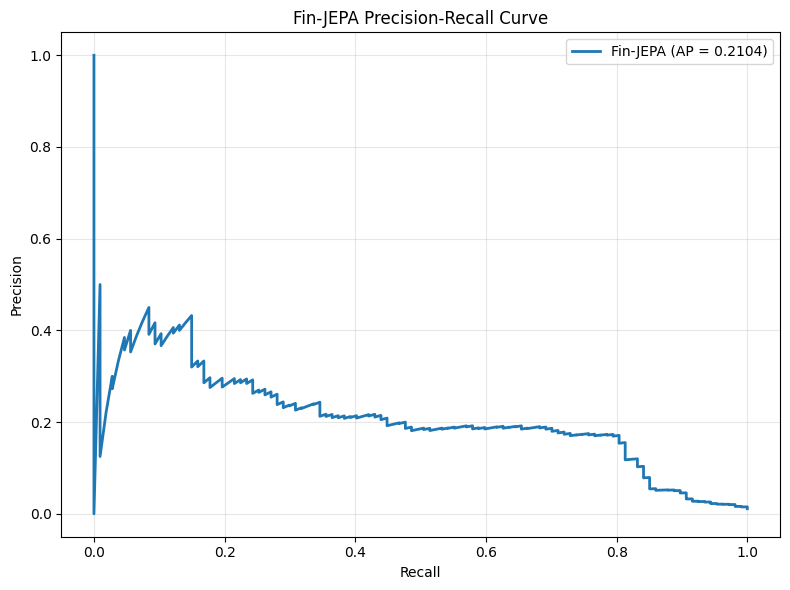


Saved:
/kaggle/working/inhouse_jepa_outputs/fin_jepa_pr_curve.png
/kaggle/working/inhouse_jepa_outputs/fin_jepa_precision_recall_table.csv


In [14]:
# ============================================================
# CELL 11 — FIN-JEPA EVALUATION
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("LOADING BEST FIN-JEPA CHECKPOINT")
print("=" * 80)

checkpoint = torch.load(
    BEST_PATH,
    map_location=device
)

fin_jepa.load_state_dict(
    checkpoint["model_state_dict"]
)

fin_jepa.eval()

print("Best epoch :", checkpoint["epoch"])
print("Best loss  :", checkpoint["loss"])


# ============================================================
# GENERATE ANOMALY SCORES
# ============================================================

all_scores = []

with torch.no_grad():

    for context, target in test_loader_fj:

        context = context.to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        output = fin_jepa(
            context,
            target
        )

        predicted = output["predicted"]
        target_latent = output["target"]

        # MSE reconstruction/prediction error
        sample_error = (
            (predicted - target_latent) ** 2
        ).mean(
            dim=(1, 2)
        )

        all_scores.append(
            sample_error.detach().cpu().numpy()
        )


fin_scores = np.concatenate(
    all_scores
)


# ============================================================
# ALIGN SCORES WITH TEST LABELS
# ============================================================

fin_results = test_labels.copy()

fin_results["fin_jepa_score"] = fin_scores


y_true = fin_results[
    "is_fraud"
].astype(int).to_numpy()

y_score = fin_results[
    "fin_jepa_score"
].to_numpy()


# ============================================================
# METRICS
# ============================================================

fin_roc_auc = roc_auc_score(
    y_true,
    y_score
)

fin_pr_auc = average_precision_score(
    y_true,
    y_score
)

precision_curve, recall_curve, thresholds = \
    precision_recall_curve(
        y_true,
        y_score
    )


print("\n" + "=" * 80)
print("FIN-JEPA TEST RESULTS")
print("=" * 80)

print("Test transactions :", len(y_true))
print("Fraud cases        :", y_true.sum())
print("Fraud rate         :", y_true.mean())

print("\nROC-AUC :", f"{fin_roc_auc:.4f}")
print("PR-AUC  :", f"{fin_pr_auc:.4f}")


# ============================================================
# PRECISION AT SELECTED RECALL VALUES
# ============================================================

target_recalls = np.arange(
    0.1,
    1.01,
    0.1
)

table_rows = []

for target_recall in target_recalls:

    # Find PR point whose recall is closest
    idx = np.argmin(
        np.abs(
            recall_curve - target_recall
        )
    )

    actual_recall = recall_curve[idx]
    precision = precision_curve[idx]

    threshold = (
        thresholds[idx]
        if idx < len(thresholds)
        else np.nan
    )

    table_rows.append({
        "Target Recall": target_recall,
        "Actual Recall": actual_recall,
        "Precision": precision,
        "Threshold": threshold
    })


fin_pr_table = pd.DataFrame(
    table_rows
)

print("\n" + "=" * 80)
print("FIN-JEPA PRECISION AT TARGET RECALL")
print("=" * 80)

display(
    fin_pr_table.style.format({
        "Target Recall": "{:.0%}",
        "Actual Recall": "{:.2%}",
        "Precision": "{:.2%}",
        "Threshold": "{:.6f}"
    })
)


# ============================================================
# SAVE TABLE
# ============================================================

OUTPUT_DIR = "/kaggle/working/inhouse_jepa_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

fin_pr_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "fin_jepa_precision_recall_table.csv"
    ),
    index=False
)


fin_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "fin_jepa_test_scores.csv"
    ),
    index=False
)


# ============================================================
# PR CURVE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Fin-JEPA (AP = {fin_pr_auc:.4f})"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Fin-JEPA Precision-Recall Curve"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

fin_pr_curve_path = os.path.join(
    OUTPUT_DIR,
    "fin_jepa_pr_curve.png"
)

plt.savefig(
    fin_pr_curve_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(fin_pr_curve_path)
print(
    os.path.join(
        OUTPUT_DIR,
        "fin_jepa_precision_recall_table.csv"
    )
)

## 14. Build the initial T-JEPA baseline

The notebook constructs a T-JEPA-style feature-masking baseline with:
- 35 input features
- Embedding dimension: **128**
- 4 attention heads
- 3 encoder layers
- 2 predictor layers
- Dropout: **0.1**
- EMA decay: **0.996**

The initial implementation is subsequently identified as architecturally incorrect.

In [15]:
# ============================================================
# CELL 12 — ORIGINAL T-JEPA ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

print("=" * 80)
print("BUILDING T-JEPA")
print("=" * 80)


# ------------------------------------------------------------
# Feature Masker
# ------------------------------------------------------------
class FeatureMasker:
    def __init__(
        self,
        n_features,
        min_context_share=0.75,
        max_context_share=0.85,
        min_target_share=0.15,
        max_target_share=0.25,
    ):
        self.n_features = n_features
        self.min_context_share = min_context_share
        self.max_context_share = max_context_share
        self.min_target_share = min_target_share
        self.max_target_share = max_target_share

    def __call__(self, batch_size, device):
        context_mask = torch.zeros(
            batch_size,
            self.n_features,
            dtype=torch.bool,
            device=device
        )

        target_mask = torch.zeros(
            batch_size,
            self.n_features,
            dtype=torch.bool,
            device=device
        )

        for i in range(batch_size):

            context_share = torch.empty(1).uniform_(
                self.min_context_share,
                self.max_context_share
            ).item()

            target_share = torch.empty(1).uniform_(
                self.min_target_share,
                self.max_target_share
            ).item()

            n_context = max(1, int(round(self.n_features * context_share)))
            n_target = max(1, int(round(self.n_features * target_share)))

            permutation = torch.randperm(
                self.n_features,
                device=device
            )

            context_idx = permutation[:n_context]

            remaining = permutation[n_context:]

            if len(remaining) < n_target:
                n_target = len(remaining)

            target_idx = remaining[:n_target]

            context_mask[i, context_idx] = True
            target_mask[i, target_idx] = True

        return context_mask, target_mask


# ------------------------------------------------------------
# Feature Tokenizer
# ------------------------------------------------------------
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, embed_dim):
        super().__init__()

        self.n_features = n_features
        self.embed_dim = embed_dim

        self.feature_embedding = nn.Parameter(
            torch.randn(n_features, embed_dim) * 0.02
        )

        self.feature_bias = nn.Parameter(
            torch.zeros(n_features, embed_dim)
        )

    def forward(self, x):
        # x: [B, F]
        tokens = (
            x.unsqueeze(-1) * self.feature_embedding.unsqueeze(0)
            + self.feature_bias.unsqueeze(0)
        )

        return tokens


# ------------------------------------------------------------
# Context Encoder
# ------------------------------------------------------------
class ContextEncoder(nn.Module):
    def __init__(
        self,
        n_features,
        embed_dim=128,
        n_heads=4,
        encoder_layers=3,
        dropout=0.1,
    ):
        super().__init__()

        self.tokenizer = FeatureTokenizer(
            n_features=n_features,
            embed_dim=embed_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=encoder_layers
        )

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, context_mask):
        tokens = self.tokenizer(x)

        # Mask features not belonging to context
        mask = ~context_mask

        encoded = self.transformer(
            tokens,
            src_key_padding_mask=mask
        )

        encoded = self.norm(encoded)

        return encoded


# ------------------------------------------------------------
# Target Encoder
# ------------------------------------------------------------
class TargetEncoder(nn.Module):
    def __init__(
        self,
        context_encoder,
    ):
        super().__init__()

        self.tokenizer = FeatureTokenizer(
            context_encoder.tokenizer.n_features,
            context_encoder.tokenizer.embed_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=context_encoder.tokenizer.embed_dim,
            nhead=4,
            dim_feedforward=context_encoder.tokenizer.embed_dim * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=3
        )

        self.norm = nn.LayerNorm(
            context_encoder.tokenizer.embed_dim
        )

    def forward(self, x, target_mask):
        tokens = self.tokenizer(x)

        mask = ~target_mask

        encoded = self.transformer(
            tokens,
            src_key_padding_mask=mask
        )

        encoded = self.norm(encoded)

        return encoded


# ------------------------------------------------------------
# Target Predictor
# ------------------------------------------------------------
class TargetPredictor(nn.Module):
    def __init__(
        self,
        embed_dim=128,
        n_heads=4,
        predictor_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            decoder_layer,
            num_layers=predictor_layers
        )

        self.norm = nn.LayerNorm(embed_dim)

        self.output_projection = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(
        self,
        context_tokens,
        target_mask,
        feature_embedding,
    ):
        # Create target-position queries from feature embeddings
        query = feature_embedding.unsqueeze(0).expand(
            context_tokens.size(0),
            -1,
            -1
        )

        # Add context information
        tokens = query + context_tokens

        tokens = self.transformer(tokens)

        tokens = self.norm(tokens)

        predictions = self.output_projection(tokens)

        return predictions


# ------------------------------------------------------------
# T-JEPA
# ------------------------------------------------------------
class TJEPA(nn.Module):

    def __init__(
        self,
        n_features,
        embed_dim=128,
        n_heads=4,
        encoder_layers=3,
        predictor_layers=2,
        dropout=0.1,
        ema_decay=0.996,
    ):
        super().__init__()

        self.ema_decay = ema_decay

        # Online/context encoder
        self.context_encoder = ContextEncoder(
            n_features=n_features,
            embed_dim=embed_dim,
            n_heads=n_heads,
            encoder_layers=encoder_layers,
            dropout=dropout,
        )

        # Target encoder
        self.target_encoder = TargetEncoder(
            self.context_encoder
        )

        # Predictor
        self.predictor = TargetPredictor(
            embed_dim=embed_dim,
            n_heads=n_heads,
            predictor_layers=predictor_layers,
            dropout=dropout,
        )

        # Initialize target encoder from context encoder
        self._copy_context_to_target()

        # Target encoder is not trained by gradient descent
        for param in self.target_encoder.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def _copy_context_to_target(self):

        context_state = self.context_encoder.state_dict()
        target_state = self.target_encoder.state_dict()

        # Copy matching parameters where possible
        for name, target_param in target_state.items():

            if name in context_state:
                source_param = context_state[name]

                if target_param.shape == source_param.shape:
                    target_param.copy_(source_param)

    @torch.no_grad()
    def update_target_encoder(self):

        decay = self.ema_decay

        context_params = dict(
            self.context_encoder.named_parameters()
        )

        target_params = dict(
            self.target_encoder.named_parameters()
        )

        for name, target_param in target_params.items():

            if name in context_params:

                source_param = context_params[name]

                target_param.data.mul_(decay)
                target_param.data.add_(
                    source_param.data,
                    alpha=1.0 - decay
                )

    def forward(
        self,
        x,
        context_mask,
        target_mask,
    ):

        # Context encoder
        context_tokens = self.context_encoder(
            x,
            context_mask
        )

        # Target encoder
        with torch.no_grad():

            target_tokens = self.target_encoder(
                x,
                target_mask
            )

        # Predictor
        predictions = self.predictor(
            context_tokens,
            target_mask,
            self.context_encoder.tokenizer.feature_embedding
        )

        return predictions, target_tokens


# ============================================================
# CREATE MODEL
# ============================================================

N_FEATURES = len(MODEL_FEATURES)

tjepa_model = TJEPA(
    n_features=N_FEATURES,
    embed_dim=128,
    n_heads=4,
    encoder_layers=3,
    predictor_layers=2,
    dropout=0.1,
    ema_decay=0.996,
).to(device)


# Count parameters
total_params = sum(
    p.numel() for p in tjepa_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in tjepa_model.parameters()
    if p.requires_grad
)


print()
print("T-JEPA configuration")
print("-" * 40)
print("Features          :", N_FEATURES)
print("Embed dim         :", 128)
print("Attention heads   :", 4)
print("Encoder layers    :", 3)
print("Predictor layers  :", 2)
print("Dropout           :", 0.1)
print("EMA decay         :", 0.996)
print("Device            :", device)
print("Total parameters  :", total_params)
print("Trainable params  :", trainable_params)

BUILDING T-JEPA

T-JEPA configuration
----------------------------------------
Features          : 35
Embed dim         : 128
Attention heads   : 4
Encoder layers    : 3
Predictor layers  : 2
Dropout           : 0.1
EMA decay         : 0.996
Device            : cuda
Total parameters  : 1621376
Trainable params  : 1017344


/tmp/ipykernel_58/82435348.py:140: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/82435348.py:188: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/82435348.py:235: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


## 15. T-JEPA forward-pass validation

This cell verifies the initial T-JEPA forward pass, including context/target masks and prediction shapes, before training.

In [16]:
# ============================================================
# CELL 13 — T-JEPA FORWARD PASS SANITY CHECK
# ============================================================

print("=" * 80)
print("T-JEPA FORWARD PASS TEST")
print("=" * 80)

tjepa_model.eval()

# ------------------------------------------------------------
# Take one training batch
# ------------------------------------------------------------
batch_size_check = min(256, len(X_train))

x_check = torch.tensor(
    X_train[:batch_size_check],
    dtype=torch.float32,
    device=device
)

# ------------------------------------------------------------
# Create feature masks
# ------------------------------------------------------------
masker_check = FeatureMasker(
    n_features=N_FEATURES,
    min_context_share=0.75,
    max_context_share=0.85,
    min_target_share=0.15,
    max_target_share=0.25,
)

context_mask_check, target_mask_check = masker_check(
    batch_size=batch_size_check,
    device=device
)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------
with torch.no_grad():

    predictions_check, targets_check = tjepa_model(
        x_check,
        context_mask_check,
        target_mask_check
    )

# ------------------------------------------------------------
# Calculate masked prediction loss
# ------------------------------------------------------------
pred_norm = F.normalize(predictions_check, dim=-1)
target_norm = F.normalize(targets_check, dim=-1)

feature_error = 1.0 - (
    pred_norm * target_norm
).sum(dim=-1)

masked_error = feature_error * target_mask_check.float()

target_count = target_mask_check.sum(
    dim=1
).clamp(min=1)

sample_loss = (
    masked_error.sum(dim=1)
    / target_count
)

loss_check = sample_loss.mean()

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
print()
print("Input shape       :", x_check.shape)
print("Context mask      :", context_mask_check.shape)
print("Target mask       :", target_mask_check.shape)
print("Predictions shape :", predictions_check.shape)
print("Targets shape     :", targets_check.shape)

print()
print("Average context features :", context_mask_check.float().sum(dim=1).mean().item())
print("Average target features  :", target_mask_check.float().sum(dim=1).mean().item())

print()
print("T-JEPA test loss :", loss_check.item())

print()
print("Forward pass successful.")

T-JEPA FORWARD PASS TEST

Input shape       : torch.Size([256, 35])
Context mask      : torch.Size([256, 35])
Target mask       : torch.Size([256, 35])
Predictions shape : torch.Size([256, 35, 128])
Targets shape     : torch.Size([256, 35, 128])

Average context features : 28.03125
Average target features  : 6.3828125

T-JEPA test loss : 1.0080527067184448

Forward pass successful.


## 16. Initial T-JEPA training

The initial T-JEPA implementation is trained for 30 epochs. Its best loss is recorded at epoch 26. This result is later excluded from the final comparison because the notebook identifies the architecture as incorrect.

In [17]:
# ============================================================
# CELL 14 — T-JEPA TRAINING
# ============================================================

import os
import copy
import numpy as np
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


print("=" * 80)
print("TRAINING T-JEPA")
print("=" * 80)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

TJEPA_EPOCHS = 30
TJEPA_LR = 1e-4
TJEPA_WEIGHT_DECAY = 1e-5
TJEPA_BATCH_SIZE = 256


# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

train_dataset_tjepa = torch.utils.data.TensorDataset(
    train_tensor
)

test_dataset_tjepa = torch.utils.data.TensorDataset(
    test_tensor
)

train_loader_tjepa = torch.utils.data.DataLoader(
    train_dataset_tjepa,
    batch_size=TJEPA_BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader_tjepa = torch.utils.data.DataLoader(
    test_dataset_tjepa,
    batch_size=TJEPA_BATCH_SIZE,
    shuffle=False,
    drop_last=False
)


# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

tjepa_model = TJEPA(
    n_features=N_FEATURES,
    embed_dim=128,
    n_heads=4,
    encoder_layers=3,
    predictor_layers=2,
    dropout=0.1,
    ema_decay=0.996,
).to(device)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer_tjepa = AdamW(
    [
        p for p in tjepa_model.parameters()
        if p.requires_grad
    ],
    lr=TJEPA_LR,
    weight_decay=TJEPA_WEIGHT_DECAY
)


scheduler_tjepa = CosineAnnealingLR(
    optimizer_tjepa,
    T_max=TJEPA_EPOCHS
)


# ------------------------------------------------------------
# Feature masker
# ------------------------------------------------------------

masker_tjepa = FeatureMasker(
    n_features=N_FEATURES,
    min_context_share=0.75,
    max_context_share=0.85,
    min_target_share=0.15,
    max_target_share=0.25,
)


# ------------------------------------------------------------
# Checkpoint directory
# ------------------------------------------------------------

checkpoint_dir = "/kaggle/working/inhouse_jepa_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

tjepa_checkpoint_path = os.path.join(
    checkpoint_dir,
    "t_jepa_best.pt"
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

best_loss_tjepa = float("inf")
best_epoch_tjepa = None

training_history_tjepa = []


for epoch in range(1, TJEPA_EPOCHS + 1):

    tjepa_model.train()

    epoch_losses = []

    for (x_batch,) in train_loader_tjepa:

        x_batch = x_batch.to(device)

        # Fresh random masks for every batch
        context_mask, target_mask = masker_tjepa(
            batch_size=x_batch.size(0),
            device=device
        )

        # Forward pass
        predictions, targets = tjepa_model(
            x_batch,
            context_mask,
            target_mask
        )

        # Normalize embeddings
        pred_norm = F.normalize(
            predictions,
            dim=-1
        )

        target_norm = F.normalize(
            targets,
            dim=-1
        )

        # Cosine prediction error
        feature_error = 1.0 - (
            pred_norm * target_norm
        ).sum(dim=-1)

        # Only target features contribute
        masked_error = (
            feature_error *
            target_mask.float()
        )

        target_count = target_mask.sum(
            dim=1
        ).clamp(min=1)

        sample_loss = (
            masked_error.sum(dim=1)
            / target_count
        )

        loss = sample_loss.mean()

        # Backpropagation
        optimizer_tjepa.zero_grad(set_to_none=True)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            tjepa_model.parameters(),
            max_norm=1.0
        )

        optimizer_tjepa.step()

        # EMA update of target encoder
        tjepa_model.update_target_encoder()

        epoch_losses.append(
            loss.detach().item()
        )

    scheduler_tjepa.step()

    epoch_loss = float(np.mean(epoch_losses))

    training_history_tjepa.append(
        epoch_loss
    )

    # Save best checkpoint
    if epoch_loss < best_loss_tjepa:

        best_loss_tjepa = epoch_loss
        best_epoch_tjepa = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": tjepa_model.state_dict(),
                "optimizer_state_dict": optimizer_tjepa.state_dict(),
                "loss": best_loss_tjepa,
            },
            tjepa_checkpoint_path
        )

        marker = " <-- BEST"

    else:
        marker = ""

    current_lr = optimizer_tjepa.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"Loss {epoch_loss:.6f} | "
        f"LR {current_lr:.2e}"
        f"{marker}"
    )


print()
print("=" * 80)
print("T-JEPA TRAINING COMPLETE")
print("=" * 80)

print("Best epoch :", best_epoch_tjepa)
print("Best loss  :", best_loss_tjepa)
print("Checkpoint :", tjepa_checkpoint_path)
print(
    "Checkpoint exists :",
    os.path.exists(tjepa_checkpoint_path)
)

TRAINING T-JEPA


/tmp/ipykernel_58/82435348.py:140: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/82435348.py:188: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/82435348.py:235: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Epoch 01 | Loss 0.441050 | LR 9.97e-05 <-- BEST
Epoch 02 | Loss 0.254770 | LR 9.89e-05 <-- BEST
Epoch 03 | Loss 0.202673 | LR 9.76e-05 <-- BEST
Epoch 04 | Loss 0.172293 | LR 9.57e-05 <-- BEST
Epoch 05 | Loss 0.154145 | LR 9.33e-05 <-- BEST
Epoch 06 | Loss 0.141606 | LR 9.05e-05 <-- BEST
Epoch 07 | Loss 0.133338 | LR 8.72e-05 <-- BEST
Epoch 08 | Loss 0.128114 | LR 8.35e-05 <-- BEST
Epoch 09 | Loss 0.122360 | LR 7.94e-05 <-- BEST
Epoch 10 | Loss 0.119335 | LR 7.50e-05 <-- BEST
Epoch 11 | Loss 0.116550 | LR 7.03e-05 <-- BEST
Epoch 12 | Loss 0.114725 | LR 6.55e-05 <-- BEST
Epoch 13 | Loss 0.113159 | LR 6.04e-05 <-- BEST
Epoch 14 | Loss 0.109833 | LR 5.52e-05 <-- BEST
Epoch 15 | Loss 0.109754 | LR 5.00e-05 <-- BEST
Epoch 16 | Loss 0.109982 | LR 4.48e-05
Epoch 17 | Loss 0.107386 | LR 3.96e-05 <-- BEST
Epoch 18 | Loss 0.106092 | LR 3.45e-05 <-- BEST
Epoch 19 | Loss 0.106659 | LR 2.97e-05
Epoch 20 | Loss 0.106155 | LR 2.50e-05
Epoch 21 | Loss 0.104818 | LR 2.06e-05 <-- BEST
Epoch 22 | Loss 0.1

## 17. Initial T-JEPA result — not used as final result

The initial T-JEPA produced **ROC-AUC 0.5230** and **PR-AUC 0.0109**. The next notebook cells explicitly state that this model used an incorrect architecture and that these metrics **must not be used as the final T-JEPA result**.

In [18]:
# ============================================================
# CELL 15 — T-JEPA EVALUATION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

print("=" * 80)
print("LOADING BEST T-JEPA CHECKPOINT")
print("=" * 80)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    "/kaggle/working/inhouse_jepa_checkpoints/t_jepa_best.pt",
    map_location=device
)

tjepa_model.load_state_dict(
    checkpoint["model_state_dict"]
)

tjepa_model.eval()

print("Best epoch :", checkpoint["epoch"])
print("Best loss  :", checkpoint["loss"])


# ------------------------------------------------------------
# IMPORTANT:
# Use deterministic evaluation masks
# ------------------------------------------------------------

EVAL_SEED = 12345

torch.manual_seed(EVAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(EVAL_SEED)


eval_masker = FeatureMasker(
    n_features=N_FEATURES,
    min_context_share=0.75,
    max_context_share=0.85,
    min_target_share=0.15,
    max_target_share=0.25,
)


# ------------------------------------------------------------
# Evaluate ALL test transactions
# ------------------------------------------------------------

all_scores = []
all_ids = []

test_transaction_ids = sequences.loc[
    sequences["split"] == "test",
    "id"
].astype(str).to_numpy()

assert len(test_transaction_ids) == len(X_test), (
    f"ID count mismatch: "
    f"{len(test_transaction_ids)} vs {len(X_test)}"
)


with torch.no_grad():

    for start in range(
        0,
        len(X_test),
        TJEPA_BATCH_SIZE
    ):

        end = min(
            start + TJEPA_BATCH_SIZE,
            len(X_test)
        )

        x_batch = torch.tensor(
            X_test[start:end],
            dtype=torch.float32,
            device=device
        )

        batch_size = x_batch.size(0)

        context_mask, target_mask = eval_masker(
            batch_size=batch_size,
            device=device
        )

        predictions, targets = tjepa_model(
            x_batch,
            context_mask,
            target_mask
        )

        # ----------------------------------------------------
        # Original T-JEPA scoring
        # ----------------------------------------------------

        pred_norm = F.normalize(
            predictions,
            dim=-1
        )

        target_norm = F.normalize(
            targets,
            dim=-1
        )

        feature_error = 1.0 - (
            pred_norm * target_norm
        ).sum(dim=-1)

        feature_error = (
            feature_error *
            target_mask.float()
        )

        target_count = target_mask.sum(
            dim=1
        ).clamp(min=1)

        sample_score = (
            feature_error.sum(dim=1)
            / target_count
        )

        all_scores.extend(
            sample_score.cpu().numpy()
        )

        all_ids.extend(
            test_transaction_ids[start:end]
        )


all_scores = np.asarray(all_scores)

all_ids = np.asarray(all_ids)


# ------------------------------------------------------------
# Build score dataframe
# ------------------------------------------------------------

tjepa_scores_df = pd.DataFrame({
    "charge_id": all_ids,
    "tjepa_score": all_scores,
})


# ------------------------------------------------------------
# Select EXACT common 9,632 IDs
# ------------------------------------------------------------

common_ids = test_charge_ids.astype(str)

common_scores_df = (
    pd.DataFrame({
        "charge_id": common_ids
    })
    .merge(
        tjepa_scores_df,
        on="charge_id",
        how="left",
        validate="one_to_one"
    )
)


assert len(common_scores_df) == 9632
assert common_scores_df["tjepa_score"].notna().all()


# ------------------------------------------------------------
# Align labels exactly with common IDs
# ------------------------------------------------------------

common_labels_df = (
    ground_truth[
        ground_truth["charge_id"].astype(str).isin(common_ids)
    ][["charge_id", "is_fraud"]]
    .copy()
)

common_labels_df["charge_id"] = (
    common_labels_df["charge_id"].astype(str)
)

common_scores_df = common_scores_df.merge(
    common_labels_df,
    on="charge_id",
    how="left",
    validate="one_to_one"
)

common_scores_df = common_scores_df[
    ["charge_id", "is_fraud", "tjepa_score"]
]


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert len(common_scores_df) == 9632
assert common_scores_df["is_fraud"].notna().all()

y_true_tjepa = (
    common_scores_df["is_fraud"]
    .astype(int)
    .to_numpy()
)

y_score_tjepa = (
    common_scores_df["tjepa_score"]
    .astype(float)
    .to_numpy()
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

roc_auc_tjepa = roc_auc_score(
    y_true_tjepa,
    y_score_tjepa
)

pr_auc_tjepa = average_precision_score(
    y_true_tjepa,
    y_score_tjepa
)


# ------------------------------------------------------------
# Precision-Recall curve
# ------------------------------------------------------------

precision_curve_tjepa, recall_curve_tjepa, thresholds_tjepa = (
    precision_recall_curve(
        y_true_tjepa,
        y_score_tjepa
    )
)


# ------------------------------------------------------------
# Precision at target recalls
# ------------------------------------------------------------

target_recalls = np.arange(
    0.1,
    1.01,
    0.1
)

rows = []

for target_recall in target_recalls:

    idx = np.argmin(
        np.abs(
            recall_curve_tjepa -
            target_recall
        )
    )

    precision_value = precision_curve_tjepa[idx]
    actual_recall = recall_curve_tjepa[idx]

    if idx < len(thresholds_tjepa):
        threshold_value = thresholds_tjepa[idx]
    else:
        threshold_value = np.nan

    rows.append({
        "Target Recall": target_recall,
        "Actual Recall": actual_recall,
        "Precision": precision_value,
        "Threshold": threshold_value,
    })


tjepa_pr_table = pd.DataFrame(rows)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print()
print("=" * 80)
print("T-JEPA COMMON TEST RESULTS")
print("=" * 80)

print("Test transactions :", len(y_true_tjepa))
print("Fraud cases        :", int(y_true_tjepa.sum()))
print(
    "Fraud rate         :",
    y_true_tjepa.mean()
)

print()
print("ROC-AUC :", f"{roc_auc_tjepa:.4f}")
print("PR-AUC  :", f"{pr_auc_tjepa:.4f}")

print()
print("=" * 80)
print("T-JEPA PRECISION AT TARGET RECALL")
print("=" * 80)

display(
    tjepa_pr_table.style.format({
        "Target Recall": "{:.0%}",
        "Actual Recall": "{:.2%}",
        "Precision": "{:.2%}",
        "Threshold": "{:.6f}",
    })
)


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

output_dir = "/kaggle/working/inhouse_jepa_outputs"

os.makedirs(
    output_dir,
    exist_ok=True
)

tjepa_pr_table.to_csv(
    os.path.join(
        output_dir,
        "tjepa_precision_recall_table.csv"
    ),
    index=False
)

common_scores_df.to_csv(
    os.path.join(
        output_dir,
        "tjepa_common_test_scores.csv"
    ),
    index=False
)


print()
print("Saved:")
print(
    os.path.join(
        output_dir,
        "tjepa_precision_recall_table.csv"
    )
)

print(
    os.path.join(
        output_dir,
        "tjepa_common_test_scores.csv"
    )
)

LOADING BEST T-JEPA CHECKPOINT
Best epoch : 26
Best loss  : 0.10338686163840669

T-JEPA COMMON TEST RESULTS
Test transactions : 9632
Fraud cases        : 107
Fraud rate         : 0.011108803986710963

ROC-AUC : 0.5230
PR-AUC  : 0.0109

T-JEPA PRECISION AT TARGET RECALL


,Target Recall,Actual Recall,Precision,Threshold
0,10%,10.28%,0.59%,0.119584
1,20%,19.63%,0.89%,0.091126
2,30%,29.91%,0.97%,0.033947
3,40%,40.19%,1.17%,0.022908
4,50%,50.47%,1.17%,0.016056
5,60%,59.81%,1.24%,0.014281
6,70%,70.09%,1.25%,0.012268
7,80%,80.37%,1.23%,0.010613
8,90%,89.72%,1.17%,0.008817
9,100%,100.00%,1.11%,0.004015



Saved:
/kaggle/working/inhouse_jepa_outputs/tjepa_precision_recall_table.csv
/kaggle/working/inhouse_jepa_outputs/tjepa_common_test_scores.csv


## 18. Architecture correction

The notebook performs an explicit parameter check and documents the architecture correction. The previously trained T-JEPA result is discarded from the final comparison.

In [19]:
# ============================================================
# CELL 16 — CHECK CURRENT T-JEPA PARAMETER COUNT
# ============================================================

print("=" * 80)
print("CURRENT T-JEPA PARAMETER CHECK")
print("=" * 80)

print("Total parameters    :", sum(
    p.numel() for p in tjepa_model.parameters()
))

print("Trainable parameters:", sum(
    p.numel()
    for p in tjepa_model.parameters()
    if p.requires_grad
))

print()
print("IMPORTANT:")
print("The previously trained T-JEPA used an incorrect architecture.")
print("We will NOT use its 0.5230 ROC-AUC / 0.0109 PR-AUC.")

CURRENT T-JEPA PARAMETER CHECK
Total parameters    : 1621376
Trainable parameters: 1017344

IMPORTANT:
The previously trained T-JEPA used an incorrect architecture.
We will NOT use its 0.5230 ROC-AUC / 0.0109 PR-AUC.


## 19. Exact source-aligned T-JEPA

The corrected T-JEPA is rebuilt using the source-aligned configuration:
- 35 features
- Embedding dimension: **128**
- 4 attention heads
- 3 encoder layers
- 2 predictor layers
- EMA decay: **0.996**

Corrected parameter count:
- Total: **1,613,440**
- Trainable: **1,013,376**

In [20]:
# ============================================================
# CELL 17 — EXACT SOURCE T-JEPA ARCHITECTURE
# ============================================================

import copy
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. EXACT FEATURE MASKER
# ============================================================

class ExactFeatureMasker:

    def __init__(
        self,
        n_features,
        min_context_share=0.75,
        max_context_share=0.85,
        min_target_share=0.15,
        max_target_share=0.25
    ):

        self.n_features = n_features

        self.min_context = max(
            1,
            int(
                math.ceil(
                    n_features * min_context_share
                )
            )
        )

        self.max_context = min(
            n_features - 1,
            int(
                math.floor(
                    n_features * max_context_share
                )
            )
        )

        self.min_target = max(
            1,
            int(
                math.ceil(
                    n_features * min_target_share
                )
            )
        )

        self.max_target = min(
            n_features - 1,
            int(
                math.floor(
                    n_features * max_target_share
                )
            )
        )

    def __call__(self, batch_size, device):

        context_masks = []
        target_masks = []

        for _ in range(batch_size):

            target_size = random.randint(
                self.min_target,
                self.max_target
            )

            context_size = random.randint(
                self.min_context,
                self.max_context
            )

            permutation = torch.randperm(
                self.n_features
            )

            target_idx = permutation[
                :target_size
            ]

            remaining = permutation[
                target_size:
            ]

            context_idx = remaining[
                :context_size
            ]

            context_mask = torch.zeros(
                self.n_features,
                dtype=torch.bool
            )

            target_mask = torch.zeros(
                self.n_features,
                dtype=torch.bool
            )

            context_mask[
                context_idx
            ] = True

            target_mask[
                target_idx
            ] = True

            context_masks.append(
                context_mask
            )

            target_masks.append(
                target_mask
            )

        return (
            torch.stack(context_masks).to(device),
            torch.stack(target_masks).to(device)
        )


# ============================================================
# 2. EXACT FEATURE TOKENIZER
# ============================================================

class ExactFeatureTokenizer(nn.Module):

    def __init__(
        self,
        n_features,
        embed_dim
    ):

        super().__init__()

        self.value_projection = nn.Linear(
            1,
            embed_dim
        )

        self.feature_embedding = nn.Parameter(
            torch.randn(
                n_features,
                embed_dim
            ) * 0.02
        )

        self.norm = nn.LayerNorm(
            embed_dim
        )

    def forward(self, x):

        value_tokens = self.value_projection(
            x.unsqueeze(-1)
        )

        feature_tokens = (
            self.feature_embedding
            .unsqueeze(0)
        )

        tokens = (
            value_tokens
            + feature_tokens
        )

        return self.norm(tokens)


# ============================================================
# 3. EXACT CONTEXT ENCODER
# ============================================================

class ExactContextEncoder(nn.Module):

    def __init__(
        self,
        n_features,
        embed_dim=128,
        n_heads=4,
        n_layers=3,
        dropout=0.1
    ):

        super().__init__()

        self.tokenizer = ExactFeatureTokenizer(
            n_features,
            embed_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.norm = nn.LayerNorm(
            embed_dim
        )

    def forward(
        self,
        x,
        context_mask
    ):

        tokens = self.tokenizer(x)

        # EXACT SOURCE BEHAVIOR:
        # non-context features are zeroed before transformer
        visible = context_mask.unsqueeze(-1)

        tokens = tokens * visible

        encoded = self.transformer(
            tokens
        )

        return self.norm(
            encoded
        )


# ============================================================
# 4. EXACT TARGET ENCODER
# ============================================================

class ExactTargetEncoder(nn.Module):

    def __init__(
        self,
        context_encoder
    ):

        super().__init__()

        self.encoder = copy.deepcopy(
            context_encoder
        )

        for parameter in self.encoder.parameters():
            parameter.requires_grad = False

    @torch.no_grad()
    def forward(
        self,
        x,
        target_mask
    ):

        tokens = self.encoder.tokenizer(x)

        encoded = self.encoder.transformer(
            tokens
        )

        encoded = self.encoder.norm(
            encoded
        )

        return encoded


# ============================================================
# 5. EXACT TARGET PREDICTOR
# ============================================================

class ExactTargetPredictor(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        n_heads=4,
        n_layers=2,
        dropout=0.1
    ):

        super().__init__()

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            decoder_layer,
            num_layers=n_layers
        )

        self.norm = nn.LayerNorm(
            embed_dim
        )

        self.output_projection = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(
        self,
        context_tokens,
        target_mask,
        feature_embedding
    ):

        B, F, D = context_tokens.shape

        # EXACT SOURCE:
        # global context representation
        context_summary = (
            context_tokens.sum(dim=1)
            /
            context_tokens.abs()
            .sum(dim=1)
            .clamp(min=1.0)
            .unsqueeze(-1)
        )

        context_summary = (
            context_summary
            .unsqueeze(1)
            .expand(-1, F, -1)
        )

        # Target feature identity
        target_tokens = (
            feature_embedding
            .unsqueeze(0)
            .expand(B, -1, -1)
        )

        predictor_input = (
            context_summary
            + target_tokens
        )

        predicted = self.transformer(
            predictor_input
        )

        predicted = self.norm(
            predicted
        )

        predicted = self.output_projection(
            predicted
        )

        return predicted


# ============================================================
# 6. EXACT T-JEPA
# ============================================================

class ExactTJEPA(nn.Module):

    def __init__(
        self,
        n_features,
        embed_dim=128,
        n_heads=4,
        encoder_layers=3,
        predictor_layers=2,
        dropout=0.1,
        ema_decay=0.996
    ):

        super().__init__()

        self.context_encoder = ExactContextEncoder(
            n_features=n_features,
            embed_dim=embed_dim,
            n_heads=n_heads,
            n_layers=encoder_layers,
            dropout=dropout
        )

        self.target_encoder = ExactTargetEncoder(
            self.context_encoder
        )

        self.predictor = ExactTargetPredictor(
            embed_dim=embed_dim,
            n_heads=n_heads,
            n_layers=predictor_layers,
            dropout=dropout
        )

        self.ema_decay = ema_decay

    @torch.no_grad()
    def update_target_encoder(self):

        for target_param, context_param in zip(
            self.target_encoder.parameters(),
            self.context_encoder.parameters()
        ):

            target_param.data.mul_(
                self.ema_decay
            )

            target_param.data.add_(
                context_param.data,
                alpha=1.0 - self.ema_decay
            )

    def forward(
        self,
        x,
        context_mask,
        target_mask
    ):

        context_tokens = self.context_encoder(
            x,
            context_mask
        )

        with torch.no_grad():

            target_tokens = self.target_encoder(
                x,
                target_mask
            )

        predictions = self.predictor(
            context_tokens,
            target_mask,
            self.context_encoder.tokenizer.feature_embedding
        )

        return (
            predictions,
            target_tokens
        )


# ============================================================
# 7. CREATE EXACT MODEL
# ============================================================

N_FEATURES = len(MODEL_FEATURES)

tjepa_exact = ExactTJEPA(
    n_features=N_FEATURES,
    embed_dim=128,
    n_heads=4,
    encoder_layers=3,
    predictor_layers=2,
    dropout=0.1,
    ema_decay=0.996
).to(device)


# ============================================================
# 8. PARAMETER CHECK
# ============================================================

total_params_exact = sum(
    p.numel()
    for p in tjepa_exact.parameters()
)

trainable_params_exact = sum(
    p.numel()
    for p in tjepa_exact.parameters()
    if p.requires_grad
)


print("=" * 80)
print("EXACT SOURCE T-JEPA")
print("=" * 80)

print("Features            :", N_FEATURES)
print("Embedding dimension :", 128)
print("Attention heads     :", 4)
print("Encoder layers      :", 3)
print("Predictor layers    :", 2)
print("EMA decay           :", 0.996)
print("Total parameters    :", total_params_exact)
print("Trainable parameters:", trainable_params_exact)

EXACT SOURCE T-JEPA
Features            : 35
Embedding dimension : 128
Attention heads     : 4
Encoder layers      : 3
Predictor layers    : 2
EMA decay           : 0.996
Total parameters    : 1613440
Trainable parameters: 1013376


/tmp/ipykernel_58/2069366475.py:212: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/2069366475.py:310: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


## 20. Rebuild the exact T-JEPA model

This cell reconstructs the corrected source-aligned model before its final training run. It is part of the reproducible correction workflow.

In [23]:
# ============================================================
# CELL 18 — FIX EXACT T-JEPA PREDICTOR
# ============================================================

class ExactTargetPredictor(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        n_heads=4,
        n_layers=2,
        dropout=0.1
    ):
        super().__init__()

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=n_layers
        )

        self.norm = nn.LayerNorm(embed_dim)

        self.output_projection = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(
        self,
        context_tokens,
        target_mask,
        feature_embedding
    ):

        B, F, D = context_tokens.shape

        # ----------------------------------------------------
        # Exact source context summary
        # ----------------------------------------------------

        numerator = context_tokens.sum(dim=1)

        denominator = (
            context_tokens.abs()
            .sum(dim=1)
            .clamp(min=1.0)
        )

        context_summary = (
            numerator / denominator
        )

        # [B, D] -> [B, 1, D] -> [B, F, D]

        context_summary = context_summary.unsqueeze(1)

        context_summary = context_summary.expand(
            -1,
            F,
            -1
        )

        # ----------------------------------------------------
        # Feature embeddings
        # ----------------------------------------------------

        target_tokens = (
            feature_embedding
            .unsqueeze(0)
            .expand(B, -1, -1)
        )

        # ----------------------------------------------------
        # Predictor input
        # ----------------------------------------------------

        predictor_input = (
            context_summary +
            target_tokens
        )

        predicted = self.transformer(
            predictor_input
        )

        predicted = self.norm(
            predicted
        )

        predicted = self.output_projection(
            predicted
        )

        return predicted

## 21. Verify the rebuilt T-JEPA

The rebuilt model is checked again for its exact parameter counts before training.

In [24]:
# ============================================================
# CELL 19 — REBUILD EXACT T-JEPA
# ============================================================

# Reproducible initialization
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


# ------------------------------------------------------------
# Create fresh exact T-JEPA
# ------------------------------------------------------------

tjepa_exact = ExactTJEPA(
    n_features=N_FEATURES,
    embed_dim=128,
    n_heads=4,
    encoder_layers=3,
    predictor_layers=2,
    dropout=0.1,
    ema_decay=0.996
).to(device)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

total_params_exact = sum(
    p.numel()
    for p in tjepa_exact.parameters()
)

trainable_params_exact = sum(
    p.numel()
    for p in tjepa_exact.parameters()
    if p.requires_grad
)


print("=" * 80)
print("REBUILT EXACT SOURCE T-JEPA")
print("=" * 80)

print(f"Total parameters    : {total_params_exact}")
print(f"Trainable parameters: {trainable_params_exact}")

REBUILT EXACT SOURCE T-JEPA
Total parameters    : 1613440
Trainable parameters: 1013376


/tmp/ipykernel_58/2069366475.py:212: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/4114272615.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


## 22. Exact T-JEPA forward-pass validation

The corrected T-JEPA successfully completes a forward-pass test with the expected masked-feature prediction shapes.

In [25]:
# ============================================================
# CELL 20 — EXACT T-JEPA FORWARD PASS TEST
# ============================================================

print("=" * 80)
print("EXACT T-JEPA FORWARD PASS TEST")
print("=" * 80)

tjepa_exact.eval()

# Reproducible mask generation
torch.manual_seed(12345)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(12345)

random.seed(12345)

# ------------------------------------------------------------
# Test batch
# ------------------------------------------------------------

batch_size_check = min(256, len(X_train))

x_check = torch.tensor(
    X_train[:batch_size_check],
    dtype=torch.float32,
    device=device
)

# ------------------------------------------------------------
# Exact source masker
# ------------------------------------------------------------

masker_check = ExactFeatureMasker(
    n_features=N_FEATURES,
    min_context_share=0.75,
    max_context_share=0.85,
    min_target_share=0.15,
    max_target_share=0.25
)

context_mask_check, target_mask_check = masker_check(
    batch_size=batch_size_check,
    device=device
)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():

    predictions_check, targets_check = tjepa_exact(
        x_check,
        context_mask_check,
        target_mask_check
    )

# ------------------------------------------------------------
# Source-style loss
# ------------------------------------------------------------

pred_norm = F.normalize(
    predictions_check,
    dim=-1
)

target_norm = F.normalize(
    targets_check,
    dim=-1
)

feature_error = 1.0 - (
    pred_norm * target_norm
).sum(dim=-1)

feature_error = (
    feature_error *
    target_mask_check.float()
)

target_count = target_mask_check.sum(
    dim=1
).clamp(min=1)

sample_loss = (
    feature_error.sum(dim=1)
    / target_count
)

loss_check = sample_loss.mean()

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print()
print("Input shape       :", x_check.shape)
print("Context mask      :", context_mask_check.shape)
print("Target mask       :", target_mask_check.shape)
print("Predictions shape :", predictions_check.shape)
print("Targets shape     :", targets_check.shape)

print()
print(
    "Average context features :",
    context_mask_check.float()
    .sum(dim=1)
    .mean()
    .item()
)

print(
    "Average target features  :",
    target_mask_check.float()
    .sum(dim=1)
    .mean()
    .item()
)

print()
print("Exact T-JEPA test loss :", loss_check.item())

print()
print("Forward pass successful.")

EXACT T-JEPA FORWARD PASS TEST

Input shape       : torch.Size([256, 35])
Context mask      : torch.Size([256, 35])
Target mask       : torch.Size([256, 35])
Predictions shape : torch.Size([256, 35, 128])
Targets shape     : torch.Size([256, 35, 128])

Average context features : 27.55859375
Average target features  : 6.98046875

Exact T-JEPA test loss : 1.0940473079681396

Forward pass successful.


## 23. Train the corrected source-aligned T-JEPA

The corrected T-JEPA is trained for **30 epochs**.

Best executed checkpoint:
- Epoch: **30**
- Training loss: **0.036538**
- Checkpoint: `t_jepa_exact_best.pt`

In [26]:
# ============================================================
# CELL 21 — TRAIN EXACT SOURCE T-JEPA
# ============================================================

import os
from torch.utils.data import DataLoader, TensorDataset

print("=" * 80)
print("TRAINING EXACT SOURCE T-JEPA")
print("=" * 80)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Fresh model with exact architecture
# ------------------------------------------------------------

tjepa_exact = ExactTJEPA(
    n_features=N_FEATURES,
    embed_dim=128,
    n_heads=4,
    encoder_layers=3,
    predictor_layers=2,
    dropout=0.1,
    ema_decay=0.996
).to(device)


# ------------------------------------------------------------
# Training data
# ------------------------------------------------------------

train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

train_dataset = TensorDataset(train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=False
)


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    tjepa_exact.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS = 30

best_loss = float("inf")
best_epoch = -1
best_state = None

checkpoint_dir = (
    "/kaggle/working/inhouse_jepa_checkpoints"
)

os.makedirs(
    checkpoint_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(1, EPOCHS + 1):

    tjepa_exact.train()

    epoch_loss = 0.0
    num_batches = 0

    for (x_batch,) in train_loader:

        x_batch = x_batch.to(device)

        # --------------------------------------------
        # Fresh random feature masks
        # --------------------------------------------

        context_mask, target_mask = masker_check(
            batch_size=x_batch.size(0),
            device=device
        )

        # --------------------------------------------
        # Forward
        # --------------------------------------------

        predictions, targets = tjepa_exact(
            x_batch,
            context_mask,
            target_mask
        )

        # --------------------------------------------
        # Normalize embeddings
        # --------------------------------------------

        pred_norm = F.normalize(
            predictions,
            dim=-1
        )

        target_norm = F.normalize(
            targets,
            dim=-1
        )

        # --------------------------------------------
        # Cosine prediction error
        # --------------------------------------------

        feature_error = 1.0 - (
            pred_norm * target_norm
        ).sum(dim=-1)

        feature_error = (
            feature_error *
            target_mask.float()
        )

        target_count = target_mask.sum(
            dim=1
        ).clamp(min=1)

        sample_loss = (
            feature_error.sum(dim=1)
            / target_count
        )

        loss = sample_loss.mean()

        # --------------------------------------------
        # Backpropagation
        # --------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            tjepa_exact.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # --------------------------------------------
        # EMA target encoder update
        # --------------------------------------------

        tjepa_exact.update_target_encoder()

        # --------------------------------------------
        # Statistics
        # --------------------------------------------

        epoch_loss += loss.item()
        num_batches += 1

    epoch_loss /= num_batches

    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"| Loss: {epoch_loss:.6f}"
    )

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if epoch_loss < best_loss:

        best_loss = epoch_loss
        best_epoch = epoch

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in tjepa_exact.state_dict().items()
        }

        checkpoint_path = os.path.join(
            checkpoint_dir,
            "t_jepa_exact_best.pt"
        )

        torch.save(
            {
                "epoch": epoch,
                "loss": epoch_loss,
                "model_state_dict": best_state
            },
            checkpoint_path
        )


# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------

tjepa_exact.load_state_dict(
    best_state
)

tjepa_exact.to(device)

print()
print("=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(f"Best epoch : {best_epoch}")
print(f"Best loss  : {best_loss:.6f}")

print(
    "Checkpoint :",
    os.path.join(
        checkpoint_dir,
        "t_jepa_exact_best.pt"
    )
)

TRAINING EXACT SOURCE T-JEPA


/tmp/ipykernel_58/2069366475.py:212: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_58/4114272615.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Epoch 01/30 | Loss: 0.256896
Epoch 02/30 | Loss: 0.130955
Epoch 03/30 | Loss: 0.119495
Epoch 04/30 | Loss: 0.088209
Epoch 05/30 | Loss: 0.050218
Epoch 06/30 | Loss: 0.044724
Epoch 07/30 | Loss: 0.042525
Epoch 08/30 | Loss: 0.041117
Epoch 09/30 | Loss: 0.040315
Epoch 10/30 | Loss: 0.039587
Epoch 11/30 | Loss: 0.039357
Epoch 12/30 | Loss: 0.038826
Epoch 13/30 | Loss: 0.038529
Epoch 14/30 | Loss: 0.038709
Epoch 15/30 | Loss: 0.038646
Epoch 16/30 | Loss: 0.038496
Epoch 17/30 | Loss: 0.038361
Epoch 18/30 | Loss: 0.038421
Epoch 19/30 | Loss: 0.038500
Epoch 20/30 | Loss: 0.039079
Epoch 21/30 | Loss: 0.039319
Epoch 22/30 | Loss: 0.039463
Epoch 23/30 | Loss: 0.039640
Epoch 24/30 | Loss: 0.039087
Epoch 25/30 | Loss: 0.039021
Epoch 26/30 | Loss: 0.038464
Epoch 27/30 | Loss: 0.038082
Epoch 28/30 | Loss: 0.037661
Epoch 29/30 | Loss: 0.036919
Epoch 30/30 | Loss: 0.036538

TRAINING COMPLETE
Best epoch : 30
Best loss  : 0.036538
Checkpoint : /kaggle/working/inhouse_jepa_checkpoints/t_jepa_exact_best.p

## 24. Score the corrected T-JEPA

The corrected T-JEPA produces anomaly scores for the full 20,725 transaction test split. The notebook then maps these scores to the common Fin-JEPA test population.

In [28]:
# ============================================================
# CELL 22 — EXACT T-JEPA TEST SCORING
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("EXACT T-JEPA TEST SCORING")
print("=" * 80)

tjepa_exact.eval()

# ------------------------------------------------------------
# Reproducible evaluation masks
# ------------------------------------------------------------

EVAL_SEED = 12345

random.seed(EVAL_SEED)
np.random.seed(EVAL_SEED)
torch.manual_seed(EVAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(EVAL_SEED)


# ------------------------------------------------------------
# Test data
# ------------------------------------------------------------

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor),
    batch_size=256,
    shuffle=False,
    drop_last=False
)


# ------------------------------------------------------------
# Exact masker
# ------------------------------------------------------------

eval_masker = ExactFeatureMasker(
    n_features=N_FEATURES,
    min_context_share=0.75,
    max_context_share=0.85,
    min_target_share=0.15,
    max_target_share=0.25
)


# ------------------------------------------------------------
# Generate scores
# ------------------------------------------------------------

all_scores = []

with torch.no_grad():

    for (x_batch,) in test_loader:

        x_batch = x_batch.to(device)

        context_mask, target_mask = eval_masker(
            batch_size=x_batch.size(0),
            device=device
        )

        predictions, targets = tjepa_exact(
            x_batch,
            context_mask,
            target_mask
        )

        # Normalize embeddings
        pred_norm = F.normalize(
            predictions,
            dim=-1
        )

        target_norm = F.normalize(
            targets,
            dim=-1
        )

        # Feature-level anomaly error
        feature_error = 1.0 - (
            pred_norm * target_norm
        ).sum(dim=-1)

        # Only target features contribute
        feature_error = (
            feature_error *
            target_mask.float()
        )

        target_count = target_mask.sum(
            dim=1
        ).clamp(min=1)

        # One anomaly score per transaction
        sample_score = (
            feature_error.sum(dim=1)
            / target_count
        )

        all_scores.extend(
            sample_score.cpu().numpy()
        )


tjepa_test_scores = np.asarray(
    all_scores,
    dtype=np.float64
)


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print()
print("Test transactions :", len(tjepa_test_scores))
print("Score min         :", tjepa_test_scores.min())
print("Score max         :", tjepa_test_scores.max())
print("Score mean        :", tjepa_test_scores.mean())
print("Score std         :", tjepa_test_scores.std())

print()
print(
    "NaN scores        :",
    np.isnan(tjepa_test_scores).sum()
)

print(
    "Inf scores        :",
    np.isinf(tjepa_test_scores).sum()
)

print()
print("T-JEPA test scoring complete.")

EXACT T-JEPA TEST SCORING

Test transactions : 20725
Score min         : 0.00047620138502679765
Score max         : 0.26481273770332336
Score mean        : 0.020913888238126354
Score std         : 0.02336944873347272

NaN scores        : 0
Inf scores        : 0

T-JEPA test scoring complete.


## 25. Recover the common Fin-JEPA test IDs

This cell recovers the 9,632 Fin-JEPA test charge IDs so that the corrected T-JEPA can be evaluated on exactly the same transactions.

In [34]:
# ============================================================
# CELL 23 — RECOVER COMMON FIN-JEPA TEST IDS
# ============================================================

print("=" * 80)
print("RECOVERING COMMON FIN-JEPA TEST IDS")
print("=" * 80)

# ------------------------------------------------------------
# The Fin-JEPA test target IDs were created during windowing.
# Check which known variable is available.
# ------------------------------------------------------------

candidate_vars = [
    "test_target_ids",
    "test_target_charge_ids",
    "test_target_id",
    "fin_test_target_ids",
    "test_ids"
]

available = {
    name: globals()[name]
    for name in candidate_vars
    if name in globals()
}

print()
print("Available candidate ID variables:")

for name, value in available.items():
    try:
        print(f"{name}: {len(value)}")
    except:
        print(f"{name}: available")

print()
print("=" * 80)

RECOVERING COMMON FIN-JEPA TEST IDS

Available candidate ID variables:



## 26. Locate the Fin-JEPA evaluation variables

The notebook inspects the current variables to identify the saved Fin-JEPA test IDs and score data needed for the common evaluation.

In [35]:
# ============================================================
# CELL 24 — FIND FIN-JEPA WINDOW VARIABLES
# ============================================================

print("=" * 80)
print("FIN-JEPA WINDOW VARIABLES")
print("=" * 80)

for name, value in sorted(globals().items()):

    if name.startswith("_"):
        continue

    try:
        shape = getattr(value, "shape", None)

        if shape is not None:
            shape_str = str(shape)

            # Show arrays/tensors related to test/window/target
            if any(
                key in name.lower()
                for key in [
                    "test",
                    "target",
                    "window",
                    "context",
                    "charge"
                ]
            ):
                print(
                    f"{name:35s} {shape_str}"
                )

    except Exception:
        pass

FIN-JEPA WINDOW VARIABLES
X_test                              (20725, 35)
X_test_tensor                       torch.Size([20725, 35])
context                             torch.Size([160, 4, 35])
context_mask                        torch.Size([245, 35])
context_mask_check                  torch.Size([256, 35])
target                              torch.Size([160, 1, 35])
target_count                        torch.Size([245])
target_latent                       torch.Size([160, 1, 64])
target_mask                         torch.Size([245, 35])
target_mask_check                   torch.Size([256, 35])
target_norm                         torch.Size([245, 35, 128])
target_recall                       ()
target_recalls                      (10,)
targets                             torch.Size([245, 35, 128])
targets_check                       torch.Size([256, 35, 128])
test_cat                            (20725, 12)
test_cat_raw                        (20725, 12)
test_charge_ids                

## 27. Final common-test T-JEPA evaluation

The corrected T-JEPA is evaluated on the **same 9,632 transactions** used by Fin-JEPA.

Final corrected T-JEPA result:
- **ROC-AUC: 0.7534**
- **PR-AUC / Average Precision: 0.0287**
- Fraud: **107**
- Non-fraud: **9,525**

This is the T-JEPA result to report; the earlier 0.5230 / 0.0109 result is explicitly rejected in the notebook.

In [36]:
# ============================================================
# CELL 25 — FINAL COMMON TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("=" * 80)
print("EXACT T-JEPA — COMMON 9,632 TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Build T-JEPA full test results
# ------------------------------------------------------------

tjepa_results = pd.DataFrame({
    "charge_id": test_rows["id"].astype(str).to_numpy(),
    "tjepa_score": tjepa_test_scores
})

# ------------------------------------------------------------
# Ground truth for all test transactions
# ------------------------------------------------------------

gt = ground_truth.copy()

gt["charge_id"] = (
    gt["charge_id"].astype(str)
)

# ------------------------------------------------------------
# Add labels
# ------------------------------------------------------------

tjepa_results = tjepa_results.merge(
    gt[
        ["charge_id", "is_fraud", "typology"]
    ],
    on="charge_id",
    how="left"
)

# ------------------------------------------------------------
# Select exact Fin-JEPA 9,632 IDs
# ------------------------------------------------------------

common_ids = set(
    test_charge_ids.astype(str)
)

common_tjepa = tjepa_results[
    tjepa_results["charge_id"].isin(common_ids)
].copy()

# ------------------------------------------------------------
# Preserve exact Fin-JEPA ordering
# ------------------------------------------------------------

id_order = {
    str(cid): i
    for i, cid in enumerate(
        test_charge_ids
    )
}

common_tjepa["order"] = (
    common_tjepa["charge_id"]
    .map(id_order)
)

common_tjepa = (
    common_tjepa
    .sort_values("order")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

print()
print(
    "Common transactions :",
    len(common_tjepa)
)

print(
    "Unique charge IDs   :",
    common_tjepa["charge_id"].nunique()
)

assert len(common_tjepa) == 9632
assert common_tjepa["is_fraud"].notna().all()

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

y_common = (
    common_tjepa["is_fraud"]
    .astype(int)
    .to_numpy()
)

scores_common = (
    common_tjepa["tjepa_score"]
    .to_numpy()
)

roc_auc = roc_auc_score(
    y_common,
    scores_common
)

pr_auc = average_precision_score(
    y_common,
    scores_common
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()
print(
    "Fraud transactions     :",
    y_common.sum()
)

print(
    "Non-fraud transactions :",
    (y_common == 0).sum()
)

print(
    f"Fraud rate             : "
    f"{100 * y_common.mean():.5f}%"
)

print()
print(
    f"T-JEPA ROC-AUC         : {roc_auc:.4f}"
)

print(
    f"T-JEPA PR-AUC          : {pr_auc:.4f}"
)

print()
print("Common-test typology:")

print(
    common_tjepa[
        "typology"
    ]
    .value_counts()
    .sort_index()
)

print()
print("=" * 80)
print("COMMON TEST EVALUATION COMPLETE")
print("=" * 80)

EXACT T-JEPA — COMMON 9,632 TEST EVALUATION

Common transactions : 9632
Unique charge IDs   : 9632

Fraud transactions     : 107
Non-fraud transactions : 9525
Fraud rate             : 1.11088%

T-JEPA ROC-AUC         : 0.7534
T-JEPA PR-AUC          : 0.0287

Common-test typology:
typology
ato         99
emerge     375
normal    9158
Name: count, dtype: int64

COMMON TEST EVALUATION COMPLETE


## 28. T-JEPA precision at target recall

The notebook calculates precision at selected recall levels and saves the corrected T-JEPA precision-recall table.

In [37]:
# ============================================================
# CELL 26 — T-JEPA PRECISION AT TARGET RECALL
# ============================================================

print("=" * 80)
print("EXACT T-JEPA — PRECISION AT TARGET RECALL")
print("=" * 80)

# ------------------------------------------------------------
# Target recall values
# ------------------------------------------------------------

target_recalls = np.arange(
    0.10,
    1.01,
    0.10
)

# ------------------------------------------------------------
# Sort transactions by anomaly score
# Highest score = most anomalous
# ------------------------------------------------------------

order = np.argsort(
    -scores_common
)

sorted_y = y_common[
    order
]

sorted_scores = scores_common[
    order
]

# ------------------------------------------------------------
# Cumulative fraud detection
# ------------------------------------------------------------

cumulative_fraud = np.cumsum(
    sorted_y
)

total_fraud = y_common.sum()

recall_curve = (
    cumulative_fraud /
    total_fraud
)

# ------------------------------------------------------------
# Build table
# ------------------------------------------------------------

rows = []

for target_recall in target_recalls:

    idx = np.searchsorted(
        recall_curve,
        target_recall,
        side="left"
    )

    idx = min(
        idx,
        len(sorted_y) - 1
    )

    k = idx + 1

    frauds_found = (
        cumulative_fraud[idx]
    )

    precision = (
        frauds_found / k
    )

    actual_recall = (
        frauds_found / total_fraud
    )

    threshold = sorted_scores[
        idx
    ]

    rows.append({
        "Target Recall": target_recall,
        "Actual Recall": actual_recall,
        "Precision": precision,
        "Predicted Positives": k,
        "Frauds Found": int(frauds_found),
        "Threshold": threshold
    })


tjepa_precision_table = pd.DataFrame(
    rows
)

# ------------------------------------------------------------
# Display percentages
# ------------------------------------------------------------

display_table = (
    tjepa_precision_table.copy()
)

display_table[
    "Target Recall"
] *= 100

display_table[
    "Actual Recall"
] *= 100

display_table[
    "Precision"
] *= 100

display_table[
    "Target Recall"
] = display_table[
    "Target Recall"
].map(
    lambda x: f"{x:.0f}%"
)

display_table[
    "Actual Recall"
] = display_table[
    "Actual Recall"
].map(
    lambda x: f"{x:.2f}%"
)

display_table[
    "Precision"
] = display_table[
    "Precision"
].map(
    lambda x: f"{x:.2f}%"
)

display_table[
    "Threshold"
] = display_table[
    "Threshold"
].map(
    lambda x: f"{x:.6f}"
)

print()
display(display_table)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

output_dir = (
    "/kaggle/working/inhouse_jepa_outputs"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

tjepa_table_path = os.path.join(
    output_dir,
    "t_jepa_exact_precision_recall_table.csv"
)

tjepa_precision_table.to_csv(
    tjepa_table_path,
    index=False
)

print()
print(
    "Saved:",
    tjepa_table_path
)

EXACT T-JEPA — PRECISION AT TARGET RECALL



,Target Recall,Actual Recall,Precision,Predicted Positives,Frauds Found,Threshold
0,10%,10.28%,4.20%,262,11,0.082952
1,20%,20.56%,3.74%,589,22,0.063576
2,30%,30.84%,2.98%,1108,33,0.049196
3,40%,40.19%,2.93%,1467,43,0.042801
4,50%,50.47%,2.79%,1935,54,0.036099
5,60%,60.75%,2.74%,2373,65,0.031127
6,70%,70.09%,2.48%,3030,75,0.024819
7,80%,80.37%,2.41%,3568,86,0.020511
8,90%,90.65%,1.75%,5544,97,0.009911
9,100%,100.00%,1.19%,9029,107,0.002771



Saved: /kaggle/working/inhouse_jepa_outputs/t_jepa_exact_precision_recall_table.csv


## 29. Check the Fin-JEPA evaluation data

This cell verifies the common evaluation dataframe and confirms the available score columns.

In [40]:
# ============================================================
# CELL 27 — CHECK FIN-JEPA SCORE COLUMN
# ============================================================

print("=" * 80)
print("FIN-JEPA EVALUATION DATA")
print("=" * 80)

print()
print("test_eval columns:")
print(
    test_eval.columns.tolist()
)

print()
print("First 5 rows:")
display(
    test_eval.head()
)

print()
print("Available numeric columns:")

for col in test_eval.columns:
    if pd.api.types.is_numeric_dtype(
        test_eval[col]
    ):
        print(
            f"{col:30s}",
            test_eval[col].min(),
            "to",
            test_eval[col].max()
        )

FIN-JEPA EVALUATION DATA

test_eval columns:
['charge_id', 'is_fraud', 'typology', 'tjepa_score']

First 5 rows:


,charge_id,is_fraud,typology,tjepa_score
0,ch_00024275,False,normal,0.003763
1,ch_00024529,False,normal,0.005339
2,ch_00034421,False,normal,0.009014
3,ch_00035519,False,normal,0.007117
4,ch_00025438,False,ato,0.016396



Available numeric columns:
is_fraud                       False to True
tjepa_score                    0.00047620138502679765 to 0.26481273770332336


## 30. Load the saved Fin-JEPA test scores

The notebook loads the saved Fin-JEPA scores for the same 9,632 charge IDs used by the corrected T-JEPA evaluation.

In [41]:
# ============================================================
# CELL 28 — LOAD FIN-JEPA TEST SCORES
# ============================================================

FIN_SCORE_FILE = (
    "/kaggle/working/inhouse_jepa_outputs/"
    "fin_jepa_test_scores.csv"
)

fin_scores_df = pd.read_csv(FIN_SCORE_FILE)

print("=" * 80)
print("FIN-JEPA SAVED SCORES")
print("=" * 80)

print()
print("Shape:", fin_scores_df.shape)

print()
print("Columns:")
print(fin_scores_df.columns.tolist())

print()
print("First 5 rows:")
display(fin_scores_df.head())

FIN-JEPA SAVED SCORES

Shape: (9632, 4)

Columns:
['charge_id', 'is_fraud', 'typology', 'fin_jepa_score']

First 5 rows:


,charge_id,is_fraud,typology,fin_jepa_score
0,ch_00032087,False,ato,0.013884
1,ch_00032096,False,ato,0.013926
2,ch_00032101,False,ato,0.013897
3,ch_00032107,False,ato,0.022698
4,ch_00032111,False,ato,0.031597


## 31. Fin-JEPA vs T-JEPA precision-recall comparison

Both models are compared on the same common test population:

| Model | PR-AUC |
|---|---:|
| **Fin-JEPA** | **0.2104** |
| **T-JEPA** | **0.0287** |

The notebook also saves a common precision-recall curve.

FIN-JEPA vs T-JEPA — PRECISION-RECALL CURVE

Common transactions : 9632
Fraud transactions   : 107
Normal transactions  : 9525
Fraud rate            : 1.1109%

Fin-JEPA PR-AUC : 0.2104
T-JEPA PR-AUC   : 0.0287


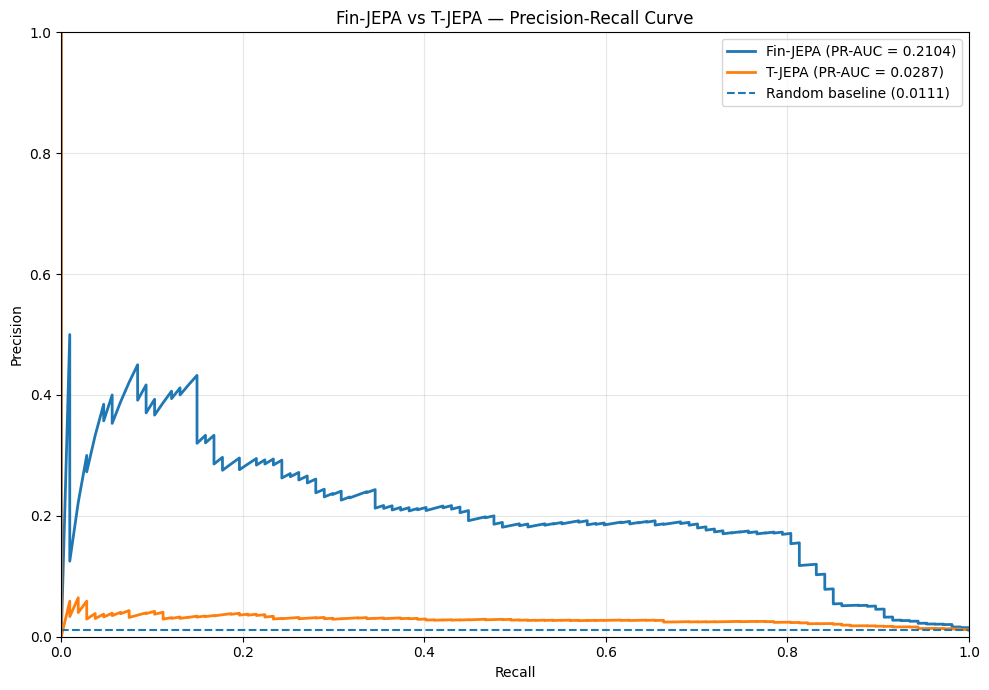


Saved PR curve:
/kaggle/working/inhouse_jepa_outputs/fin_vs_tjepa_pr_curve.png


In [42]:
# ============================================================
# CELL 29 — FIN-JEPA vs T-JEPA PRECISION-RECALL CURVE
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Align both models by charge_id
# ------------------------------------------------------------

fin_pr = fin_scores_df[
    ["charge_id", "is_fraud", "fin_jepa_score"]
].copy()

t_pr = test_eval[
    ["charge_id", "is_fraud", "tjepa_score"]
].copy()

common_pr = fin_pr.merge(
    t_pr,
    on="charge_id",
    suffixes=("_fin", "_t")
)

# ------------------------------------------------------------
# 2. Use the common fraud labels
# ------------------------------------------------------------

y_pr = common_pr["is_fraud_fin"].astype(int).to_numpy()

fin_scores_pr = common_pr[
    "fin_jepa_score"
].to_numpy()

tjepa_scores_pr = common_pr[
    "tjepa_score"
].to_numpy()

print("=" * 80)
print("FIN-JEPA vs T-JEPA — PRECISION-RECALL CURVE")
print("=" * 80)

print()
print("Common transactions :", len(common_pr))
print("Fraud transactions   :", y_pr.sum())
print("Normal transactions  :", len(y_pr) - y_pr.sum())
print(
    "Fraud rate            : "
    f"{y_pr.mean() * 100:.4f}%"
)

# ------------------------------------------------------------
# 3. Calculate PR curves
# ------------------------------------------------------------

fin_precision, fin_recall, _ = precision_recall_curve(
    y_pr,
    fin_scores_pr
)

tjepa_precision, tjepa_recall, _ = precision_recall_curve(
    y_pr,
    tjepa_scores_pr
)

# ------------------------------------------------------------
# 4. Calculate PR-AUC
# ------------------------------------------------------------

fin_pr_auc = average_precision_score(
    y_pr,
    fin_scores_pr
)

tjepa_pr_auc = average_precision_score(
    y_pr,
    tjepa_scores_pr
)

print()
print(f"Fin-JEPA PR-AUC : {fin_pr_auc:.4f}")
print(f"T-JEPA PR-AUC   : {tjepa_pr_auc:.4f}")

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.plot(
    fin_recall,
    fin_precision,
    linewidth=2,
    label=f"Fin-JEPA (PR-AUC = {fin_pr_auc:.4f})"
)

plt.plot(
    tjepa_recall,
    tjepa_precision,
    linewidth=2,
    label=f"T-JEPA (PR-AUC = {tjepa_pr_auc:.4f})"
)

# Random baseline
random_baseline = y_pr.mean()

plt.axhline(
    random_baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Random baseline ({random_baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Fin-JEPA vs T-JEPA — Precision-Recall Curve")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------

OUTPUT_DIR = "/kaggle/working/inhouse_jepa_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PR_CURVE_PATH = os.path.join(
    OUTPUT_DIR,
    "fin_vs_tjepa_pr_curve.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved PR curve:")
print(PR_CURVE_PATH)

## 32. Precision at selected recall values

The notebook calculates precision at target recall levels from 10% through 100% and saves the final comparison table.

In [43]:
# ============================================================
# CELL 30 — PRECISION AT SELECTED RECALL VALUES
# ============================================================

import numpy as np
import pandas as pd
import os

TARGET_RECALLS = np.arange(
    0.10,
    1.01,
    0.10
)

def precision_at_target_recall(
    y_true,
    scores,
    target_recall
):
    """
    Select the highest-scoring transactions until
    the requested recall is reached.
    """

    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)

    order = np.argsort(-scores)

    sorted_y = y_true[order]

    cumulative_fraud = np.cumsum(sorted_y)

    total_fraud = y_true.sum()

    recall_curve = (
        cumulative_fraud / total_fraud
    )

    idx = np.searchsorted(
        recall_curve,
        target_recall,
        side="left"
    )

    idx = min(
        idx,
        len(y_true) - 1
    )

    k = idx + 1

    frauds_found = cumulative_fraud[idx]

    precision = (
        frauds_found / k
    )

    actual_recall = (
        frauds_found / total_fraud
    )

    threshold = scores[
        order[idx]
    ]

    return (
        k,
        frauds_found,
        precision,
        actual_recall,
        threshold
    )


# ------------------------------------------------------------
# Generate table
# ------------------------------------------------------------

rows = []

for target in TARGET_RECALLS:

    (
        fin_k,
        fin_frauds,
        fin_precision,
        fin_actual_recall,
        fin_threshold
    ) = precision_at_target_recall(
        y_pr,
        fin_scores_pr,
        target
    )

    (
        tjepa_k,
        tjepa_frauds,
        tjepa_precision,
        tjepa_actual_recall,
        tjepa_threshold
    ) = precision_at_target_recall(
        y_pr,
        tjepa_scores_pr,
        target
    )

    rows.append({
        "Target Recall": target,

        "Fin-JEPA Actual Recall":
            fin_actual_recall,

        "Fin-JEPA Precision":
            fin_precision,

        "Fin-JEPA Predicted Positives":
            fin_k,

        "Fin-JEPA Fraud Found":
            fin_frauds,

        "Fin-JEPA Threshold":
            fin_threshold,

        "T-JEPA Actual Recall":
            tjepa_actual_recall,

        "T-JEPA Precision":
            tjepa_precision,

        "T-JEPA Predicted Positives":
            tjepa_k,

        "T-JEPA Fraud Found":
            tjepa_frauds,

        "T-JEPA Threshold":
            tjepa_threshold
    })


precision_table = pd.DataFrame(rows)

# ------------------------------------------------------------
# Display percentage values nicely
# ------------------------------------------------------------

display_table = precision_table.copy()

for col in [
    "Target Recall",
    "Fin-JEPA Actual Recall",
    "Fin-JEPA Precision",
    "T-JEPA Actual Recall",
    "T-JEPA Precision"
]:
    display_table[col] = (
        display_table[col] * 100
    ).round(2)

display_table["Fin-JEPA Threshold"] = (
    display_table["Fin-JEPA Threshold"]
    .round(6)
)

display_table["T-JEPA Threshold"] = (
    display_table["T-JEPA Threshold"]
    .round(6)
)

print("=" * 120)
print(
    "FIN-JEPA vs T-JEPA — PRECISION AT SELECTED RECALL"
)
print("=" * 120)

display(display_table)


# ------------------------------------------------------------
# Save full table
# ------------------------------------------------------------

OUTPUT_DIR = (
    "/kaggle/working/"
    "inhouse_jepa_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

TABLE_PATH = os.path.join(
    OUTPUT_DIR,
    "fin_vs_tjepa_precision_recall_table.csv"
)

precision_table.to_csv(
    TABLE_PATH,
    index=False
)

print()
print("Saved:")
print(TABLE_PATH)

FIN-JEPA vs T-JEPA — PRECISION AT SELECTED RECALL


,Target Recall,Fin-JEPA Actual Recall,Fin-JEPA Precision,Fin-JEPA Predicted Positives,Fin-JEPA Fraud Found,Fin-JEPA Threshold,T-JEPA Actual Recall,T-JEPA Precision,T-JEPA Predicted Positives,T-JEPA Fraud Found,T-JEPA Threshold
0,10.0,10.28,39.29,28,11,0.288662,10.28,4.20,262,11,0.082952
1,20.0,20.56,28.57,77,22,0.240924,20.56,3.74,589,22,0.063576
2,30.0,30.84,24.09,137,33,0.192762,30.84,2.98,1108,33,0.049196
3,40.0,40.19,21.39,201,43,0.158994,40.19,2.93,1467,43,0.042801
4,50.0,50.47,18.69,289,54,0.132551,50.47,2.79,1935,54,0.036099
5,60.0,60.75,18.73,347,65,0.116010,60.75,2.74,2373,65,0.031127
6,70.0,70.09,18.66,402,75,0.104726,70.09,2.48,3030,75,0.024819
7,80.0,80.37,17.10,503,86,0.088885,80.37,2.41,3568,86,0.020511
8,90.0,90.65,4.58,2119,97,0.033921,90.65,1.75,5544,97,0.009911
9,100.0,100.00,1.51,7085,107,0.013261,100.00,1.19,9029,107,0.002771



Saved:
/kaggle/working/inhouse_jepa_outputs/fin_vs_tjepa_precision_recall_table.csv


## 33. Environment / Git status check

The final cell checks the current working directory and Git state. In the supplied execution, the Kaggle working directory is not itself a Git repository; the reproducible notebook is therefore intended to be copied into the GitHub repository separately.

In [44]:
!pwd
!git status
!git remote -v

/kaggle/working
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
